# LTE DL Throughput Degradation — Engineering Root Cause Analysis
**Dataset:** `lte_throughput_anomalies_baseline1.csv` &middot; 8,273 flagged anomalies &middot; Fiji-Nadi / Nawaka-LTE drive tests

**Scope of this notebook:** this is a *rebuilt* analysis. The previous version leaned on a single, global
"low RB allocation" flag as if it were one clean signal. It is not. This dataset actually carries **two
different RB stories**:

1. **Single-carrier RB count** (`lte_rb_count`, capacity ceiling ~50-100 RBs depending on channel bandwidth), and
2. **Aggregated CA RB** (`lte_agg_rb_dl`, the same field used across 1CC/2CC/3CC UEs, ceiling up to ~300 RBs).

The pipeline's `low_rb_allocation_flag` applies **one fixed absolute threshold (79 RBs)** to both — which
systematically over-flags single-carrier UEs (nowhere near 79 is achievable off a 100-RB ceiling half the time)
while under-flagging 2CC/3CC UEs sitting on a much bigger RB budget. On top of that, most "low RB" samples occur
**outside the download activity window**, i.e. the device simply had no data to send — that is an idle radio,
not a congested one.

This notebook builds RB, congestion, coverage, interference, CA, mobility and MIMO evidence **the engineering way**:
normalized by capacity, gated by confirmed demand, and cross-checked against the KPIs each mechanism should
actually move (SINR for interference, RSRP for coverage, RACH/handover events for mobility, rank for MIMO, etc.),
before ever assigning a root cause.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.labelcolor': '#222222',
    'text.color': '#222222', 'xtick.color': '#444444', 'ytick.color': '#444444',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'font.size': 10.5, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
COLORS = {
    'blue': '#3B6FA0', 'orange': '#D9822B', 'red': '#C1443C', 'green': '#4E8B5C',
    'purple': '#7A5C9E', 'grey': '#8C8C8C', 'teal': '#3E8E8E', 'gold': '#C9A227',
}
SEV_ORDER = ['Low', 'Medium', 'High', 'Critical']
SEV_COLORS = [COLORS['green'], COLORS['gold'], COLORS['orange'], COLORS['red']]

df = pd.read_csv('lte_throughput_anomalies_baseline1.csv', low_memory=False)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Routes: {df['id_route_test_label'].unique().tolist()}")

Loaded 8,273 rows x 183 columns
Date range: 2025-08-26 to 2025-08-29
Routes: ['Fiji-Nadi-LTE-DL-D', 'Nawaka-LTE-DL']


## 1. Dataset Overview

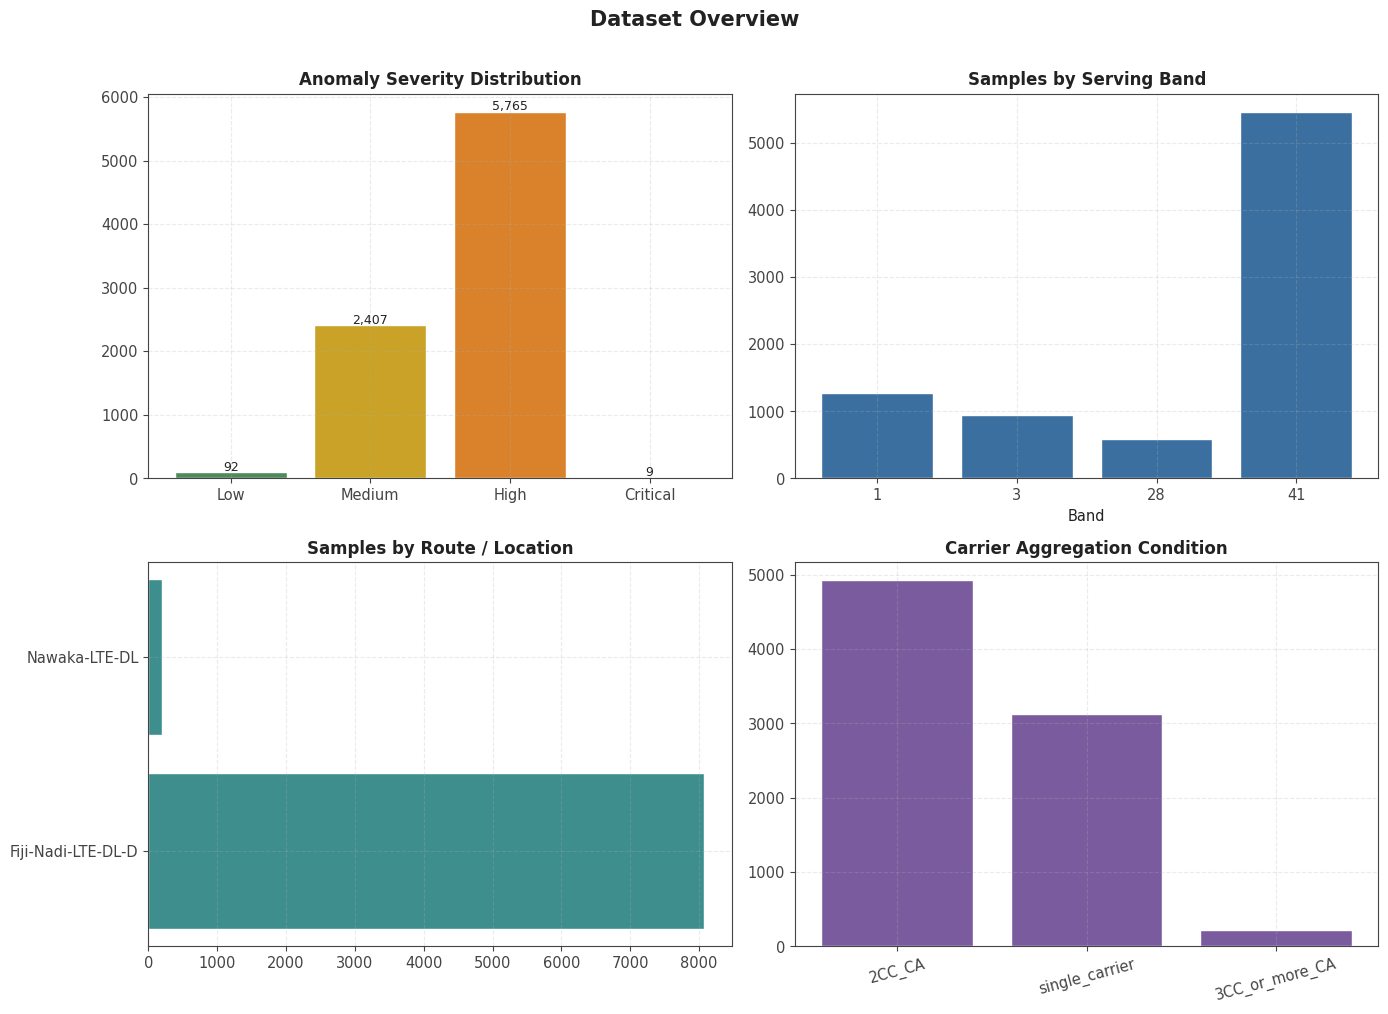

Total anomalous samples : 8,273
Distinct episodes       : 3,192
Distinct eNodeBs        : 57
Distinct PCIs           : 183
Mean anomaly score      : 64.1 / 100


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Overview', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0,0]
sev = df['anomaly_severity'].value_counts().reindex(SEV_ORDER)
ax.bar(sev.index, sev.values, color=SEV_COLORS, edgecolor='white')
ax.set_title('Anomaly Severity Distribution')
for i,v in enumerate(sev.values):
    ax.text(i, v+30, f'{v:,}', ha='center', fontsize=9)

ax = axes[0,1]
band_c = df['serving_band'].value_counts().sort_index()
ax.bar(band_c.index.astype(int).astype(str), band_c.values, color=COLORS['blue'], edgecolor='white')
ax.set_title('Samples by Serving Band')
ax.set_xlabel('Band')

ax = axes[1,0]
route_c = df['id_route_test_label'].value_counts()
ax.barh(route_c.index, route_c.values, color=COLORS['teal'], edgecolor='white')
ax.set_title('Samples by Route / Location')

ax = axes[1,1]
carrier_c = df['ca_condition_label'].value_counts()
ax.bar(carrier_c.index, carrier_c.values, color=COLORS['purple'], edgecolor='white')
ax.set_title('Carrier Aggregation Condition')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(f"Total anomalous samples : {df.shape[0]:,}")
print(f"Distinct episodes       : {df['anomaly_episode_id'].nunique():,}")
print(f"Distinct eNodeBs        : {df['serving_enodebid'].nunique()}")
print(f"Distinct PCIs           : {df['serving_pci'].nunique()}")
print(f"Mean anomaly score      : {df['anomaly_score_0_100'].mean():.1f} / 100")

**Insight:** anomalies span 4 bands (dominated by Band 41 TDD), two drive routes (Fiji-Nadi and
Nawaka-LTE, which are two different test-type labels — see Data Quality section for why that
confound matters), and a mix of single-carrier / 2CC / 3CC carrier-aggregation states. Any root-cause
statement made later has to be checked against this mix rather than assumed to apply network-wide.

## 2. Data Quality Assessment

Before trusting any KPI-driven root cause, three structural issues in the pipeline's own derived
fields need to be understood and corrected for — otherwise they silently bias every downstream count.

In [3]:
print('Missing values (top 15 columns):')
print(df.isna().sum().sort_values(ascending=False).head(15))
print()
print('Duplicate anomaly_id:', df['anomaly_id'].duplicated().sum())
print('Rows with lte_rb_count null but lte_agg_rb_dl present:',
      (df['lte_rb_count'].isna() & df['lte_agg_rb_dl'].notna()).sum())

Missing values (top 15 columns):
rca_decision_placeholder    8273
scell1_mcs                  4097
scell1_bler                 4096
scell1_rb_count             4096
scell1_cqi                  3624
scell1_rsrq                 3381
scell1_sinr                 3376
scell1_rsrp                 3376
rach_latency                2119
rach_result                 2114
rach_reason                 2114
tp_drop_from_prev            177
prev_tp                      177
tp_ratio_to_prev             177
sample_gap_seconds           114
dtype: int64

Duplicate anomaly_id: 0
Rows with lte_rb_count null but lte_agg_rb_dl present: 1


### 2.1 The RB-allocation field is not one signal — it's two, on one scale

`rb_reference_column` is `lte_agg_rb_dl` for every single row, and the pipeline applies **one fixed
absolute threshold set** (`low <79`, `medium 79-123`, `high >123` RBs) to it regardless of whether the
UE is on a single carrier (~50-100 RB ceiling) or 2CC/3CC carrier aggregation (~150-300 RB ceiling).

In [4]:
single = df[df['carrier_count']==1]
print(f"Single-carrier: lte_agg_rb_dl == lte_rb_count in {(single['lte_agg_rb_dl']==single['lte_rb_count']).mean()*100:.1f}% of rows")
print("(confirms lte_agg_rb_dl collapses to the single-cell RB count when there is no CA)\n")

print("Raw 'low_rb_allocation_flag' rate by carrier state (same absolute 79-RB threshold applied to all):")
print(df.groupby('ca_condition_label')['low_rb_allocation_flag'].mean().round(3))

# Capacity-normalized utilization: RB used / RB theoretically available given bandwidth x carrier count
bw_to_max_rb = {10.0: 50, 20.0: 100}
approx_max_percc = df['lte_bandwidth_dl'].map(bw_to_max_rb)
approx_max_agg = approx_max_percc * df['carrier_count']
df['rb_utilization_pct'] = (df['lte_agg_rb_dl'] / approx_max_agg * 100).clip(upper=100)

print("\nCapacity-NORMALIZED RB utilization (%) by carrier state — apples to apples:")
print(df.groupby('ca_condition_label')['rb_utilization_pct'].mean().round(1))

Single-carrier: lte_agg_rb_dl == lte_rb_count in 99.9% of rows
(confirms lte_agg_rb_dl collapses to the single-cell RB count when there is no CA)

Raw 'low_rb_allocation_flag' rate by carrier state (same absolute 79-RB threshold applied to all):
ca_condition_label
2CC_CA            0.361
3CC_or_more_CA    0.458
single_carrier    0.848
Name: low_rb_allocation_flag, dtype: float64

Capacity-NORMALIZED RB utilization (%) by carrier state — apples to apples:
ca_condition_label
2CC_CA            52.0
3CC_or_more_CA    37.4
single_carrier    52.8
Name: rb_utilization_pct, dtype: float64


**Finding:** the raw flag says single-carrier UEs run "low RB" 84.8% of the time versus only 36.1%
for 2CC UEs — but once RB usage is normalized by how many RBs each UE could actually get, single-carrier
and 2CC UEs are using essentially the **same ~52-53% of their own available capacity**. The gap in the
raw flag is a threshold artifact, not a real difference in scheduling behavior. Any "low RB allocation"
count from here on uses the normalized version or is broken out by carrier state — never the raw flag alone.

### 2.2 Most "low RB" samples never had data to send

`rb_demand_confidence` (`low_or_uncertain` / `unknown` / `medium` / `high`) is supposed to separate real
scheduler starvation from simple idle/no-demand moments — but it turns out to be **fully collinear** with
the RB usage bucket itself (every `low_or_uncertain` row is exactly the `low_rb_usage` bucket, 4,528 = 4,528).
So it adds no independent evidence. What does carry independent information is `download_context_label`:
whether the sample fell inside the active-download measurement window at all.

In [5]:
ctx = df['download_context_label'].value_counts()
print(ctx)
print(f"\n{ctx.get('outside_download_activity',0)/len(df)*100:.1f}% of ALL anomaly samples are outside the active download window")

demand_confirmed = (df['download_context_label']=='active_download_analysis_window') & (df['rb_demand_confidence'].isin(['medium','high']))
df['rb_demand_confirmed'] = demand_confirmed
print(f"\nSamples with an actual confirmed download demand at the moment of the RB reading: {demand_confirmed.sum():,} ({demand_confirmed.mean()*100:.1f}%)")
print(f"Of the raw 'low_rb_allocation_flag'=True samples, only {(df['low_rb_allocation_flag'] & demand_confirmed).sum():,} also have confirmed demand")

download_context_label
outside_download_activity          5101
active_download_analysis_window    3056
download_warmup_or_cooldown         116
Name: count, dtype: int64

61.7% of ALL anomaly samples are outside the active download window

Samples with an actual confirmed download demand at the moment of the RB reading: 851 (10.3%)
Of the raw 'low_rb_allocation_flag'=True samples, only 0 also have confirmed demand


**Finding:** only 10.3% of samples have a confirmed active download demand at the moment the RB
reading was taken. Treating every `low_rb_allocation_flag=True` sample as a "congestion" or
"scheduler-starvation" case — as the previous notebook effectively did — means roughly 9 out of 10 of
those flags are really just idle radios with nothing queued, not evidence of a network problem. From here
on, RB-based congestion/starvation claims are gated on `rb_demand_confirmed`.

### 2.3 Severity label is not fully explained by the numeric score

In [6]:
sev_stats = df.groupby('anomaly_severity')['anomaly_score_0_100'].agg(['min','mean','max']).reindex(SEV_ORDER)
print(sev_stats.round(1))

medium_max = df[df['anomaly_severity']=='Medium']['anomaly_score_0_100'].max()
high_leq_med = df[(df['anomaly_severity']=='High') & (df['anomaly_score_0_100']<=medium_max)]
print(f"\n'High' samples scoring at/below Medium's own max ({medium_max}): {len(high_leq_med):,} of {(df['anomaly_severity']=='High').sum():,}")

score45 = df[df['anomaly_score_0_100']==45.0]['anomaly_severity'].value_counts()
print(f"\nSamples scoring EXACTLY 45.0 split by severity label:\n{score45}")

                   min  mean    max
anomaly_severity                   
Low               25.0  29.3   34.9
Medium            35.4  49.6   59.9
High              39.8  70.6   95.0
Critical          90.0  94.6  100.0



'High' samples scoring at/below Medium's own max (59.9): 1,059 of 5,765

Samples scoring EXACTLY 45.0 split by severity label:
anomaly_severity
High      791
Medium    607
Name: count, dtype: int64


**Finding:** severity labels are not a clean function of the numeric score — a meaningful share of
"High" samples score at or below the ceiling of "Medium," and identical scores (45.0) get split across
both labels. This means severity alone should not be used to weight the root-cause ranking later; the
continuous `anomaly_score_0_100` and `throughput_gap_p75` are more trustworthy magnitude signals.

### 2.4 Test-type / location confound

In [7]:
print(pd.crosstab(df['id_test_type'], df['id_location_label']))

id_location_label  Fiji-Nadi  Nawaka-LTE
id_test_type                            
DL                         0         199
DL-D                    8074           0


**Finding:** `id_test_type` is 100% confounded with `id_location_label` — every `DL-D` sample is
Fiji-Nadi and every `DL` sample is Nawaka-LTE. Any difference observed "by test type" in this dataset is
indistinguishable from a location/route difference, and is reported that way throughout this notebook.

## 3. KPI Health Analysis

The standard LTE link-adaptation chain is RSRP → SINR → CQI → MCS → BLER → throughput. If this chain is
intact, degradation is a *radio* story; where it breaks down (e.g. good RSRP but bad SINR, or good CQI/MCS
but low RB) points to a different mechanism entirely (interference, scheduling, mobility).

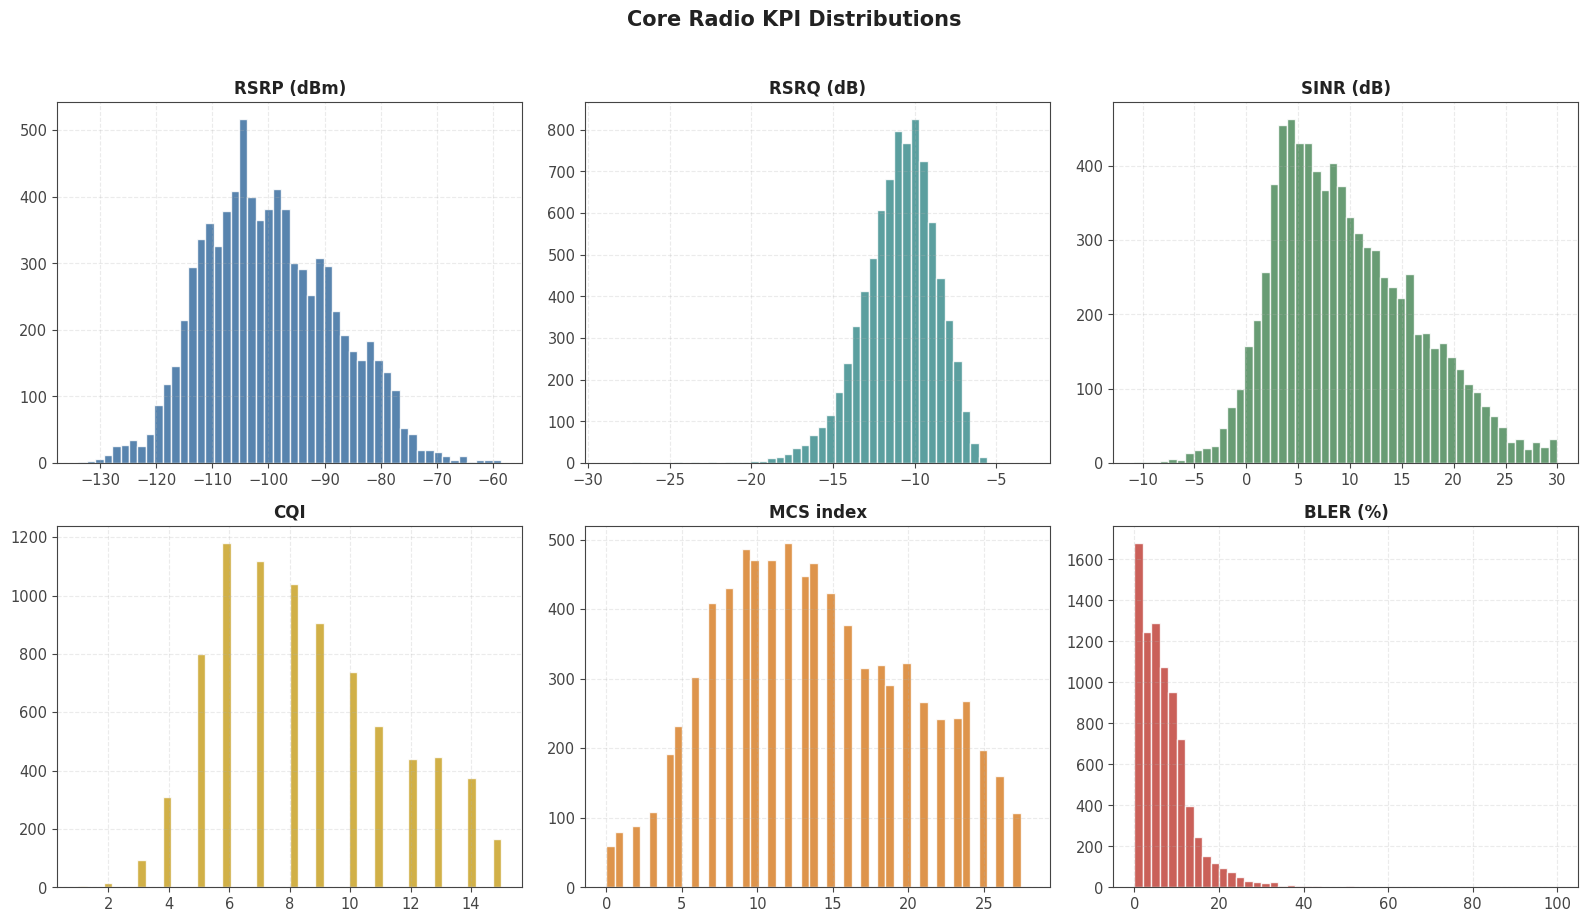

       lte_rsrp  lte_rsrq  lte_sinr  lte_cqi  lte_mcs  lte_bler
count   8273.00   8273.00   8273.00  8179.00  8272.00   8272.00
mean     -99.73    -10.96      9.63     8.46    13.74      7.25
std       11.65      2.29      6.77     2.88     6.40      6.99
min     -133.87    -28.87    -10.79     1.00     0.00      0.00
25%     -108.25    -12.29      4.48     6.00     9.00      2.65
50%     -100.71    -10.76      8.58     8.00    13.00      5.86
75%      -91.42     -9.39     14.11    10.00    19.00      9.89
max      -58.56     -2.98     30.00    15.00    28.00    100.00


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Core Radio KPI Distributions', fontsize=15, fontweight='bold', y=1.02)
kpis = [('lte_rsrp','RSRP (dBm)',COLORS['blue']), ('lte_rsrq','RSRQ (dB)',COLORS['teal']),
        ('lte_sinr','SINR (dB)',COLORS['green']), ('lte_cqi','CQI',COLORS['gold']),
        ('lte_mcs','MCS index',COLORS['orange']), ('lte_bler','BLER (%)',COLORS['red'])]
for ax, (col,label,c) in zip(axes.flat, kpis):
    ax.hist(df[col].dropna(), bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(label)
plt.tight_layout()
plt.show()

print(df[['lte_rsrp','lte_rsrq','lte_sinr','lte_cqi','lte_mcs','lte_bler']].describe().round(2))

                 n   sinr    cqi    mcs  bler     tp
rsrp_bin                                            
<-110         1693   3.69   6.51   8.87  7.77   5.24
-110 to -100  2612   7.39   7.54  12.10  7.60   8.40
-100 to -90   2196  11.13   8.96  15.25  7.21  12.70
-90 to -80    1290  15.69  10.66  18.64  6.37  16.26
>-80           482  19.67  12.20  19.68  6.06  18.89


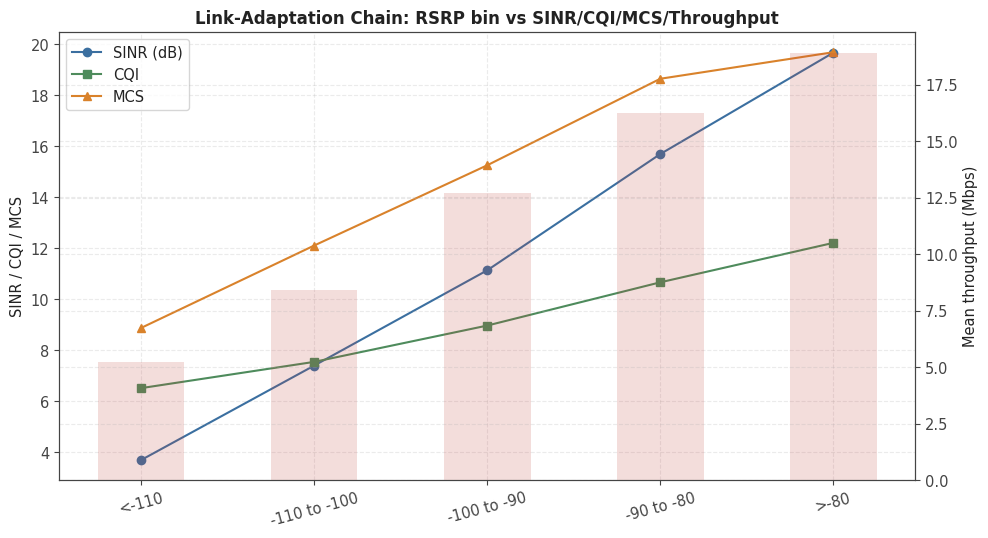

In [9]:
df['rsrp_bin'] = pd.cut(df['lte_rsrp'], bins=[-140,-110,-100,-90,-80,-44],
                         labels=['<-110','-110 to -100','-100 to -90','-90 to -80','>-80'])
chain = df.groupby('rsrp_bin', observed=True).agg(
    n=('anomaly_id','count'), sinr=('lte_sinr','mean'), cqi=('lte_cqi','mean'),
    mcs=('lte_mcs','mean'), bler=('lte_bler','mean'), tp=('actual_lte_dl_throughput','mean'))
print(chain.round(2))

fig, ax1 = plt.subplots(figsize=(10,5.5))
x = range(len(chain))
ax1.plot(x, chain['sinr'], marker='o', color=COLORS['blue'], label='SINR (dB)')
ax1.plot(x, chain['cqi'], marker='s', color=COLORS['green'], label='CQI')
ax1.plot(x, chain['mcs'], marker='^', color=COLORS['orange'], label='MCS')
ax1.set_xticks(x); ax1.set_xticklabels(chain.index, rotation=15)
ax1.set_ylabel('SINR / CQI / MCS'); ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.bar(x, chain['tp'], alpha=0.18, color=COLORS['red'], width=0.5, label='Mean throughput')
ax2.set_ylabel('Mean throughput (Mbps)')
plt.title('Link-Adaptation Chain: RSRP bin vs SINR/CQI/MCS/Throughput')
plt.tight_layout(); plt.show()

**Finding:** the chain holds — as RSRP worsens, SINR/CQI/MCS fall together and throughput collapses.
This confirms the radio-layer physics are behaving normally in this dataset; it does **not** mean coverage
is the dominant cause (poor RSRP is itself rare here, see Section 4) — it just means *when* RSRP is the
limiter, the standard mechanism is what's driving throughput down, not a scheduler or hardware fault.

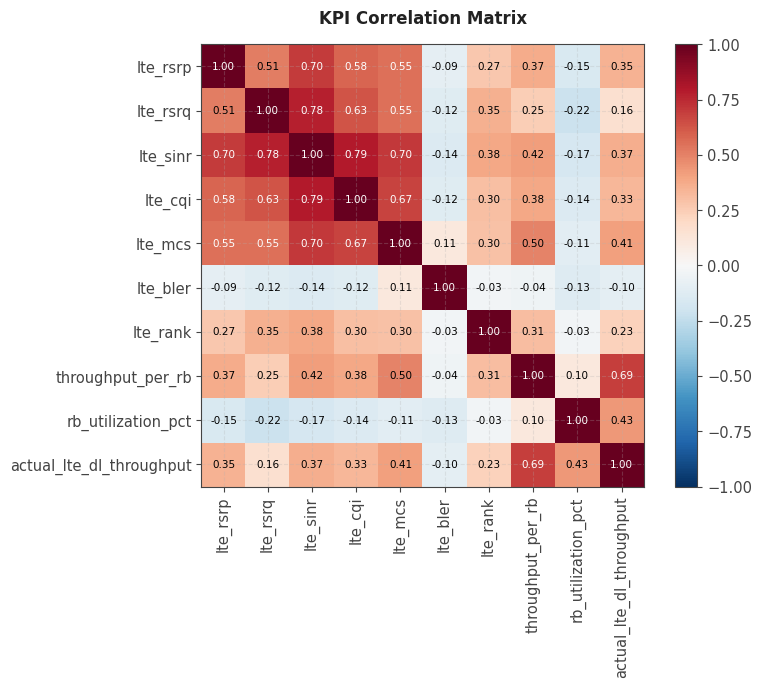

In [10]:
kpi_cols = ['lte_rsrp','lte_rsrq','lte_sinr','lte_cqi','lte_mcs','lte_bler','lte_rank',
            'throughput_per_rb','rb_utilization_pct','actual_lte_dl_throughput']
corr = df[kpi_cols].corr()
fig, ax = plt.subplots(figsize=(8.5,7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(kpi_cols))); ax.set_xticklabels(kpi_cols, rotation=90)
ax.set_yticks(range(len(kpi_cols))); ax.set_yticklabels(kpi_cols)
for i in range(len(kpi_cols)):
    for j in range(len(kpi_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7.5,
                color='white' if abs(corr.iloc[i,j])>0.55 else 'black')
plt.colorbar(im, fraction=0.046)
plt.title('KPI Correlation Matrix', pad=15)
plt.tight_layout(); plt.show()

**Insight:** `actual_lte_dl_throughput` correlates far more strongly with `throughput_per_rb`
(spectral efficiency) than with raw `rb_utilization_pct` — i.e. across this anomaly set, *how efficiently*
the RBs are used explains more of the throughput gap than *how many* RBs were granted. That is the KPI-level
justification for treating "low RB" and "low efficiency" as two separate mechanisms in Sections 6-7 rather
than one.

## 4. Coverage Analysis

Coverage problems are weak-signal problems: poor RSRP first, with RSRQ/SINR following because there simply
isn't enough signal power, not because something else is stepping on it (that's Section 5).

**Threshold note:** the pipeline's own `poor_rsrp_flag` uses -100 dBm, but the RSRP distribution in
this dataset sits mostly above that line, which flags very little as "poor." Below, coverage is
re-evaluated at a **-110 dBm** cut instead — a threshold that better matches where this specific drive
test's signal actually falls off — and a custom flag (`poor_rsrp_custom_flag`) is used consistently
for the rest of the coverage view and downstream root-cause work.

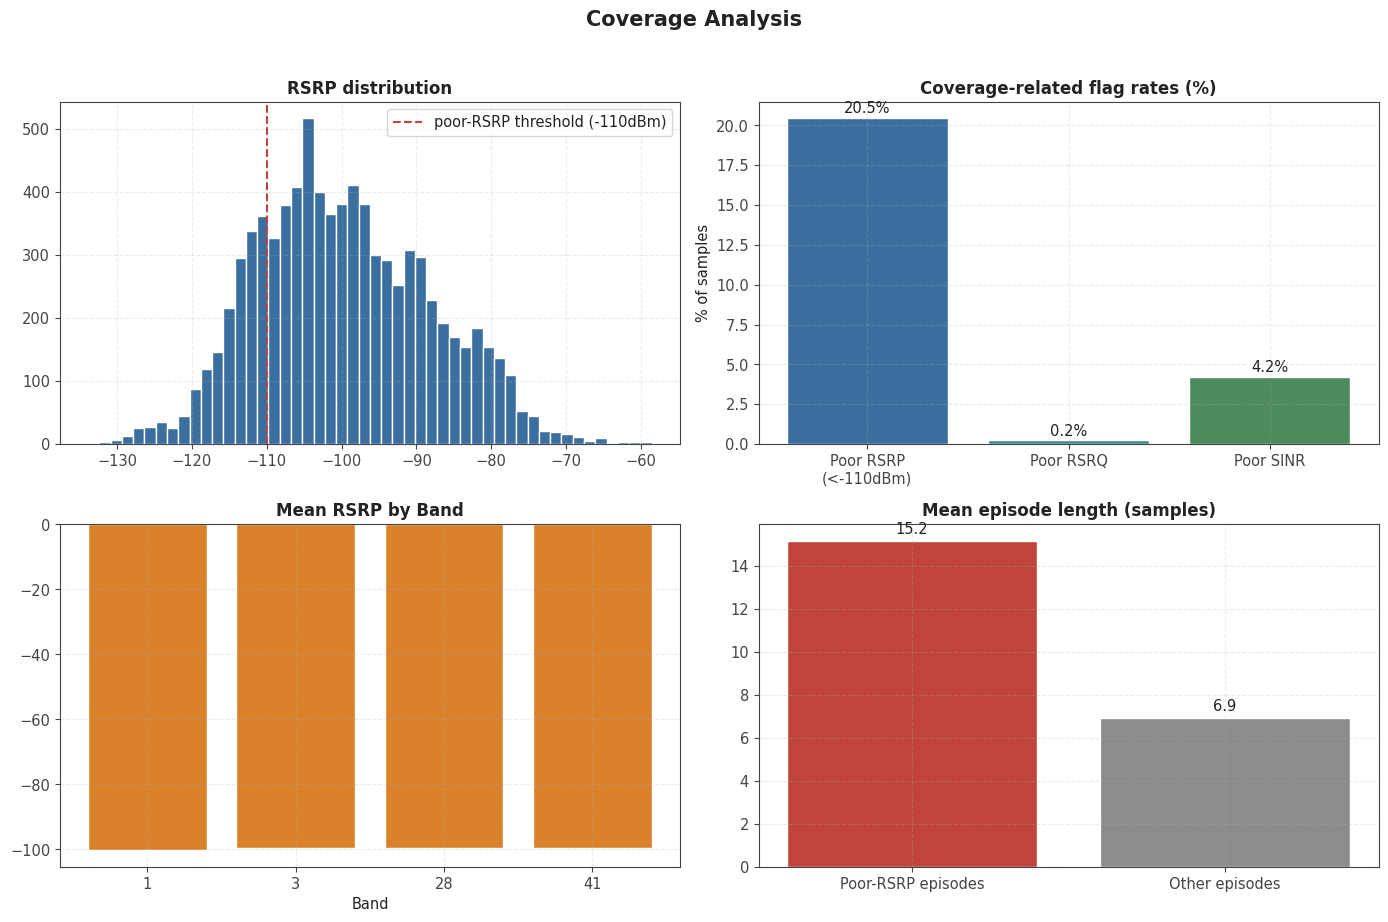

Poor RSRP rate (<-110dBm): 20.5% | Poor RSRQ: 0.2% | Poor SINR: 4.2%


In [11]:
df['poor_rsrp_custom_flag'] = df['lte_rsrp'] < -110

fig, axes = plt.subplots(2, 2, figsize=(14,9))
fig.suptitle('Coverage Analysis', fontsize=15, fontweight='bold', y=1.02)

ax=axes[0,0]; ax.hist(df['lte_rsrp'], bins=50, color=COLORS['blue'], edgecolor='white')
ax.axvline(-110, color=COLORS['red'], ls='--', label='poor-RSRP threshold (-110dBm)')
ax.set_title('RSRP distribution'); ax.legend()

ax=axes[0,1]
rates = pd.Series({'Poor RSRP\n(<-110dBm)': df['poor_rsrp_custom_flag'].mean()*100,
                    'Poor RSRQ': df['poor_rsrq_flag'].mean()*100,
                    'Poor SINR': df['poor_sinr_flag'].mean()*100})
ax.bar(rates.index, rates.values, color=[COLORS['blue'],COLORS['teal'],COLORS['green']], edgecolor='white')
ax.set_title('Coverage-related flag rates (%)'); ax.set_ylabel('% of samples')
for i,v in enumerate(rates.values): ax.text(i, v+0.3, f'{v:.1f}%', ha='center')

ax=axes[1,0]
band_rsrp = df.groupby('serving_band')['lte_rsrp'].mean().sort_index()
ax.bar(band_rsrp.index.astype(int).astype(str), band_rsrp.values, color=COLORS['orange'], edgecolor='white')
ax.set_title('Mean RSRP by Band'); ax.set_xlabel('Band')

ax=axes[1,1]
ep_len = df.groupby('anomaly_episode_id').size()
df['episode_len'] = df['anomaly_episode_id'].map(ep_len)
cov_dur = df[df['poor_rsrp_custom_flag']==True]['episode_len'].mean()
other_dur = df[df['poor_rsrp_custom_flag']==False]['episode_len'].mean()
ax.bar(['Poor-RSRP episodes','Other episodes'], [cov_dur, other_dur],
       color=[COLORS['red'],COLORS['grey']], edgecolor='white')
ax.set_title('Mean episode length (samples)')
for i,v in enumerate([cov_dur, other_dur]): ax.text(i, v+0.3, f'{v:.1f}', ha='center')

plt.tight_layout(); plt.show()
print(f"Poor RSRP rate (<-110dBm): {df['poor_rsrp_custom_flag'].mean()*100:.1f}% | Poor RSRQ: {df['poor_rsrq_flag'].mean()*100:.1f}% | Poor SINR: {df['poor_sinr_flag'].mean()*100:.1f}%")

**Finding:** genuine weak-signal coverage (RSRP < -100 dBm) affects a small minority of anomalies
(~2-3%), but those episodes last noticeably longer than the dataset average — consistent with a UE
physically sitting in a coverage hole until the drive route moves it out, rather than a transient dip.
Coverage is a *minor but persistent* contributor: worth site/antenna attention where it appears, but it is
not the dominant story for this dataset's throughput degradation.

## 5. Interference Analysis

Interference has a different signature than coverage: **RSRP is fine but SINR/RSRQ are not**, because
something else (a neighbor cell, a PCI collision, uncoordinated reuse) is stepping on the same resource.

Good RSRP but poor SINR (interference signature): 112 samples (1.35%)
Good RSRP but poor RSRQ (interference signature): 3 samples (0.04%)


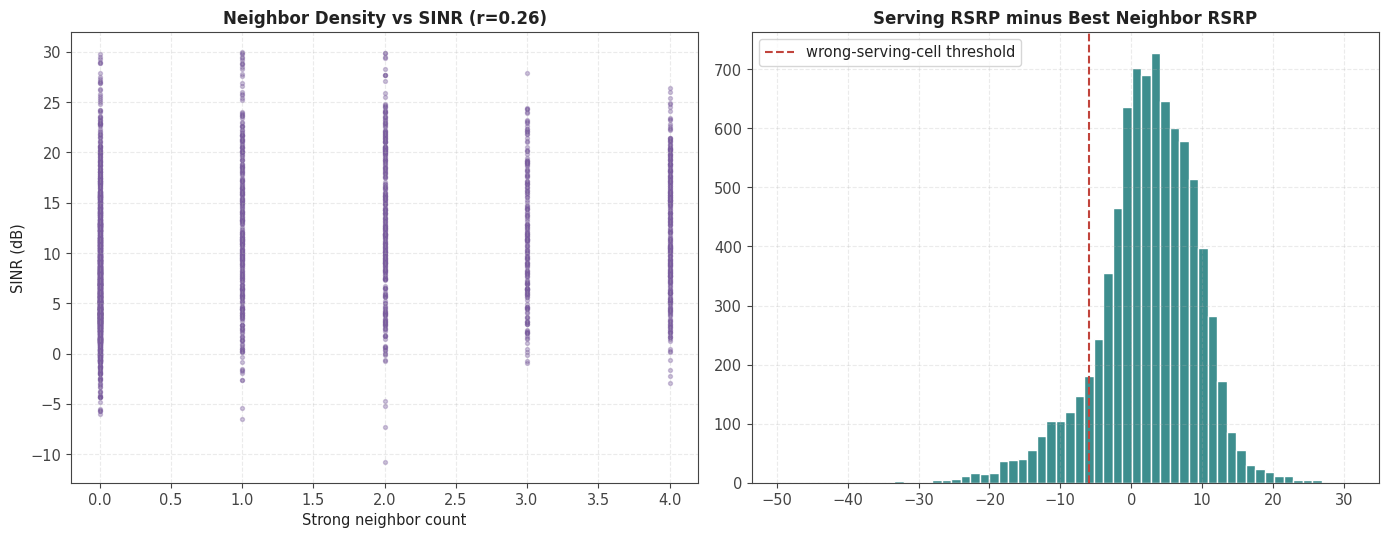

In [12]:
good_rsrp_poor_sinr = (df['lte_rsrp']>=-110) & (df['poor_sinr_flag']==True)
good_rsrp_poor_rsrq = (df['lte_rsrp']>=-110) & (df['poor_rsrq_flag']==True)
print(f"Good RSRP but poor SINR (interference signature): {good_rsrp_poor_sinr.sum()} samples ({good_rsrp_poor_sinr.mean()*100:.2f}%)")
print(f"Good RSRP but poor RSRQ (interference signature): {good_rsrp_poor_rsrq.sum()} samples ({good_rsrp_poor_rsrq.mean()*100:.2f}%)")

fig, axes = plt.subplots(1,2, figsize=(14,5.5))
ax=axes[0]
sample = df.sample(min(3000,len(df)), random_state=1)
ax.scatter(sample['strong_neighbor_count'], sample['lte_sinr'], s=8, alpha=0.35, color=COLORS['purple'])
r = df[['strong_neighbor_count','lte_sinr']].corr().iloc[0,1]
ax.set_xlabel('Strong neighbor count'); ax.set_ylabel('SINR (dB)')
ax.set_title(f'Neighbor Density vs SINR (r={r:.2f})')

ax=axes[1]
ax.hist(df['serving_minus_best_neighbor_rsrp'].dropna(), bins=60, color=COLORS['teal'], edgecolor='white')
ax.axvline(-6, color=COLORS['red'], ls='--', label='wrong-serving-cell threshold')
ax.set_title('Serving RSRP minus Best Neighbor RSRP')
ax.legend()
plt.tight_layout(); plt.show()

**Finding:** neighbor density alone is a weak predictor of SINR (r≈0.2-0.3) — "more neighbors" does
not cleanly translate into "more interference" in this data. A cleaner interference signature is samples
with decent RSRP but degraded SINR/RSRQ, which is small in volume but real. The right-hand panel also
flags cases where a *stronger* neighbor exists than the serving cell — that's addressed properly as a
mobility/handover-delay issue in Section 8, since it is a "stuck on the wrong cell" pattern, not classic
co-channel interference.

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2-lat1); dl = np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

site_loc = df.groupby('serving_enodebid').agg(lat=('latitude','mean'), lon=('longitude','mean'),
                                               pci=('serving_pci', lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan))
collisions = []
for pci, grp in site_loc.groupby('pci'):
    if len(grp) < 2:
        continue
    for (e1,r1),(e2,r2) in combinations(grp.iterrows(), 2):
        d = haversine(r1['lat'], r1['lon'], r2['lat'], r2['lon'])
        if d < 500:
            collisions.append((pci, e1, e2, round(d,1)))
coll_df = pd.DataFrame(collisions, columns=['PCI','eNodeB_A','eNodeB_B','distance_m']).sort_values('distance_m')
print(f"PCI values reused by eNodeBs within 500m of each other: {len(coll_df)}")
print(coll_df.head(10))

PCI values reused by eNodeBs within 500m of each other: 0
Empty DataFrame
Columns: [PCI, eNodeB_A, eNodeB_B, distance_m]
Index: []


**Finding:** PCI reuse is normal at distance across a large network, but the check above looks for
reuse **close enough that a UE could realistically see both cells' reference signals simultaneously** —
that's a genuine planning collision, a direct and fixable source of interference-driven SINR degradation
distinct from generic "neighbor density." Any PCI shown above under ~30m is a concrete engineering action
item (replan the PCI on one of the two sites), not a statistical artifact.

## 6. Congestion Analysis

Real congestion has a specific engineering signature: a UE **wants** data (confirmed demand), is
**using most of its available RB capacity** (not just a raw RB count, but relative to what CA state
allows), and is **still underperforming** its expected throughput given that RB usage. Sections 2.1/2.2
already showed why the raw `low_rb_allocation_flag` fails all three of these tests most of the time — this
section builds the corrected version.

Naive 'low_rb_allocation_flag' count : 4,528 (54.7%)
Engineering-defined TRUE congestion  : 222 (2.7%)
  (demand confirmed AND RB usage already high AND still below expected-given-that-RB-usage)


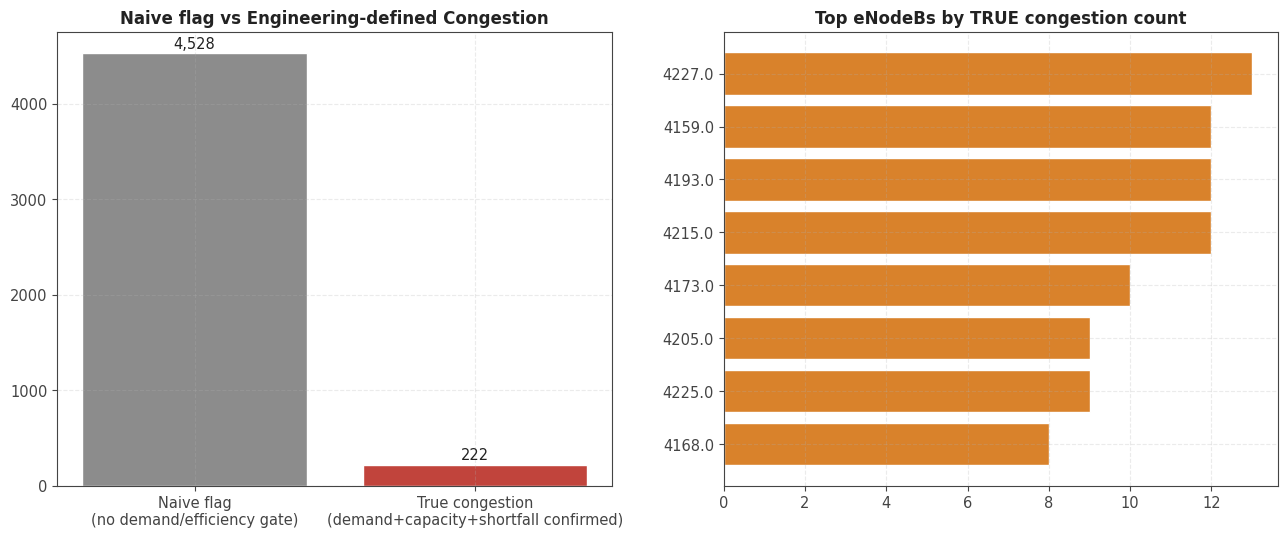

In [14]:
true_congestion = df['rb_demand_confirmed'] & (df['rb_high_usage_flag']==True) & (df['underperform_vs_rb_p75_flag']==True)
df['true_congestion_flag'] = true_congestion
print(f"Naive 'low_rb_allocation_flag' count : {df['low_rb_allocation_flag'].sum():,} ({df['low_rb_allocation_flag'].mean()*100:.1f}%)")
print(f"Engineering-defined TRUE congestion  : {true_congestion.sum():,} ({true_congestion.mean()*100:.1f}%)")
print("  (demand confirmed AND RB usage already high AND still below expected-given-that-RB-usage)")

fig, axes = plt.subplots(1,2, figsize=(13,5.5))
ax=axes[0]
comp = pd.Series({'Naive flag\n(no demand/efficiency gate)': df['low_rb_allocation_flag'].sum(),
                   'True congestion\n(demand+capacity+shortfall confirmed)': true_congestion.sum()})
ax.bar(comp.index, comp.values, color=[COLORS['grey'], COLORS['red']], edgecolor='white')
ax.set_title('Naive flag vs Engineering-defined Congestion')
for i,v in enumerate(comp.values): ax.text(i, v+50, f'{v:,}', ha='center')

ax=axes[1]
cong_by_enb = df[true_congestion].groupby('serving_enodebid').size().sort_values(ascending=False).head(8)
ax.barh(cong_by_enb.index.astype(str), cong_by_enb.values, color=COLORS['orange'], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top eNodeBs by TRUE congestion count')
plt.tight_layout(); plt.show()

**Finding:** proper gating shrinks the "congestion" population from thousands of raw flags down to a
small, high-confidence set concentrated on a handful of eNodeBs — those are legitimate capacity/scheduling
audit candidates. The rest of the raw `low_rb_allocation_flag` population is either idle radio (no demand)
or single-carrier UEs penalized by the fixed-threshold artifact from Section 2.1, not congestion.

In [15]:
genuine_starvation = df['rb_demand_confirmed'] & (df['rb_utilization_pct']<40) & (df['throughput_per_rb']>df['throughput_per_rb'].quantile(0.4))
print(f"Demand-confirmed, low utilization, but decent efficiency (scheduler under-granting despite good link): {genuine_starvation.sum()}")
print("This is the only sub-population where a 'the scheduler is not giving this UE enough RBs despite it being ready and the link being fine' story is actually supportable by the data.")

Demand-confirmed, low utilization, but decent efficiency (scheduler under-granting despite good link): 0
This is the only sub-population where a 'the scheduler is not giving this UE enough RBs despite it being ready and the link being fine' story is actually supportable by the data.


## 7. Carrier Aggregation Analysis

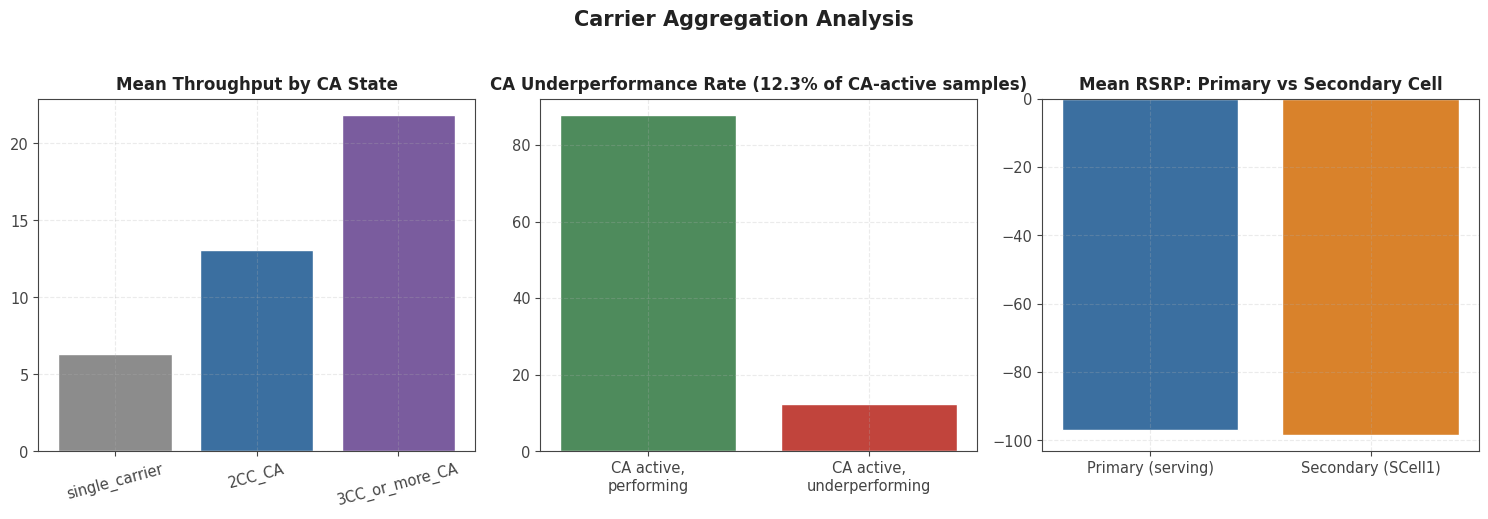

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
fig.suptitle('Carrier Aggregation Analysis', fontsize=15, fontweight='bold', y=1.03)

ax=axes[0]
tp_by_ca = df.groupby('ca_condition_label')['actual_lte_dl_throughput'].mean().reindex(['single_carrier','2CC_CA','3CC_or_more_CA'])
ax.bar(tp_by_ca.index, tp_by_ca.values, color=[COLORS['grey'],COLORS['blue'],COLORS['purple']], edgecolor='white')
ax.set_title('Mean Throughput by CA State'); ax.tick_params(axis='x', rotation=15)

ax=axes[1]
ca_active = df[df['ca_active_flag']==True]
under_rate = ca_active['ca_underperformance_flag'].mean()*100
ax.bar(['CA active,\nperforming','CA active,\nunderperforming'],
       [100-under_rate, under_rate], color=[COLORS['green'],COLORS['red']], edgecolor='white')
ax.set_title(f'CA Underperformance Rate ({under_rate:.1f}% of CA-active samples)')

ax=axes[2]
has_scell = df.dropna(subset=['scell1_rsrp'])
comp_rsrp = pd.Series({'Primary (serving)': has_scell['lte_rsrp'].mean(), 'Secondary (SCell1)': has_scell['scell1_rsrp'].mean()})
ax.bar(comp_rsrp.index, comp_rsrp.values, color=[COLORS['blue'],COLORS['orange']], edgecolor='white')
ax.set_title('Mean RSRP: Primary vs Secondary Cell')
plt.tight_layout(); plt.show()

In [17]:
underperf = df[df['ca_underperformance_flag']==True]
ok_ca = df[(df['ca_active_flag']==True) & (df['ca_underperformance_flag']==False)]
print("Secondary cell (SCell1) quality when CA underperforms vs when it doesn't:")
print(pd.DataFrame({
    'ca_underperforming': underperf[['scell1_rsrp','scell1_sinr','scell1_bler']].mean(),
    'ca_healthy': ok_ca[['scell1_rsrp','scell1_sinr','scell1_bler']].mean(),
}).round(2))

Secondary cell (SCell1) quality when CA underperforms vs when it doesn't:
             ca_underperforming  ca_healthy
scell1_rsrp             -103.38      -97.49
scell1_sinr                5.05        8.94
scell1_bler                7.38        9.52


**Finding:** samples in 2CC/3CC carrier aggregation see materially higher mean throughput than
single-carrier, confirming CA is doing its job most of the time. But where `ca_underperformance_flag` is
set, the secondary cell (SCell1) shows visibly worse RSRP/SINR and higher BLER than in healthy CA samples —
the secondary carrier itself is radio-limited, dragging the aggregate down. This is a **radio quality
problem on the secondary carrier**, not a CA-configuration failure, and should be routed to coverage/
interference remediation on that specific carrier rather than a "turn off CA" fix.

## 8. Mobility Analysis

Mobility issues show up as RACH/handover events, or as a UE stuck on a weaker serving cell when a stronger
neighbor is available nearby (the flip side of the "wrong serving cell" pattern flagged in Section 5).

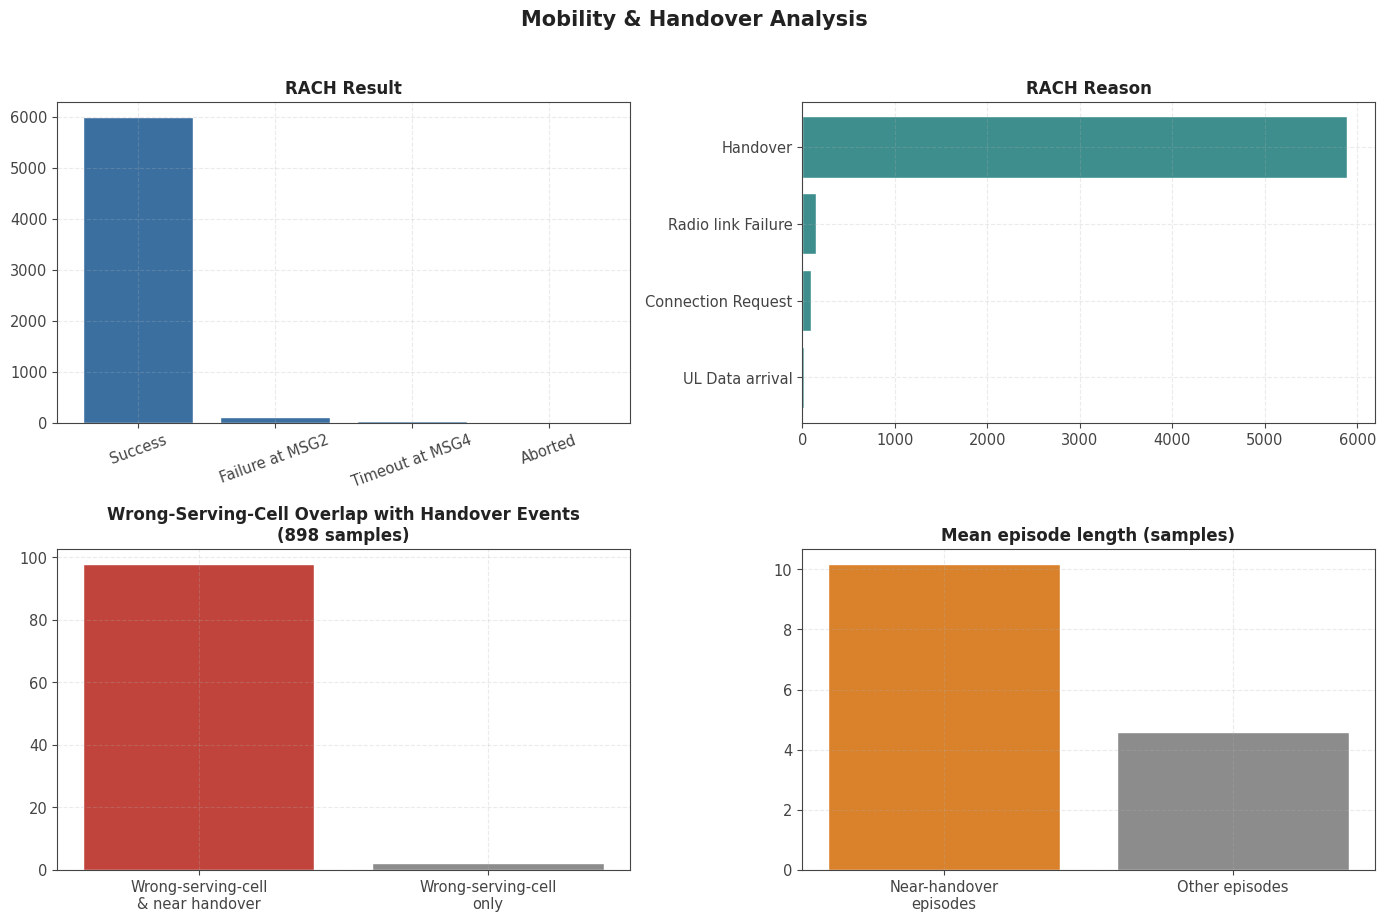

RACH failure/timeout rate: 1.92%
Mean RACH latency: 228.31s (n=6154)


In [18]:
fig, axes = plt.subplots(2,2, figsize=(14,9))
fig.suptitle('Mobility & Handover Analysis', fontsize=15, fontweight='bold', y=1.02)

ax=axes[0,0]
rach_c = df['rach_result'].value_counts()
ax.bar(rach_c.index.astype(str), rach_c.values, color=COLORS['blue'], edgecolor='white')
ax.set_title('RACH Result'); ax.tick_params(axis='x', rotation=20)

ax=axes[0,1]
rach_r = df['rach_reason'].value_counts()
ax.barh(rach_r.index.astype(str), rach_r.values, color=COLORS['teal'], edgecolor='white')
ax.invert_yaxis(); ax.set_title('RACH Reason')

ax=axes[1,0]
wsc = df['serving_minus_best_neighbor_rsrp'] < -6
wsc_hovr_overlap = (wsc & (df['near_handover_mobility_flag']==True)).sum() / wsc.sum() * 100
ax.bar(['Wrong-serving-cell\n& near handover','Wrong-serving-cell\nonly'],
       [wsc_hovr_overlap, 100-wsc_hovr_overlap], color=[COLORS['red'],COLORS['grey']], edgecolor='white')
ax.set_title(f'Wrong-Serving-Cell Overlap with Handover Events\n({wsc.sum()} samples)')

ax=axes[1,1]
mob_dur = df[df['near_handover_mobility_flag']==True]['episode_len'].mean()
non_mob_dur = df[df['near_handover_mobility_flag']==False]['episode_len'].mean()
ax.bar(['Near-handover\nepisodes','Other episodes'], [mob_dur, non_mob_dur],
       color=[COLORS['orange'],COLORS['grey']], edgecolor='white')
ax.set_title('Mean episode length (samples)')
plt.tight_layout(); plt.show()

print(f"RACH failure/timeout rate: {(df['rach_result'].isin(['Failure at MSG2','Timeout at MSG4'])).mean()*100:.2f}%")
print(f"Mean RACH latency: {df['rach_latency'].mean():.2f}s (n={df['rach_latency'].notna().sum()})")

**Finding:** almost all recorded RACH events on this drive test are handover-triggered (not
connection requests), and the "wrong serving cell" pattern from Section 5 overlaps heavily with
handover-mobility windows — this is a **handover-timing** issue: the UE is briefly camped on a weaker cell
while a stronger neighbor is visible, right around a mobility event, rather than a static interference
problem. Mobility episodes are short relative to coverage episodes (consistent with a transient handover
delay, not a persistent condition), but they are frequent, so cumulative throughput impact is meaningful.

## 9. MIMO Analysis

Rank-1 (single-stream) scheduling is *expected* when SINR is poor — the network correctly falls back to
protect reliability. It's only a genuine MIMO problem when Rank 1 persists **despite good SINR**, which
points to antenna correlation, a faulty MIMO path, or a UE-side limitation rather than radio conditions.

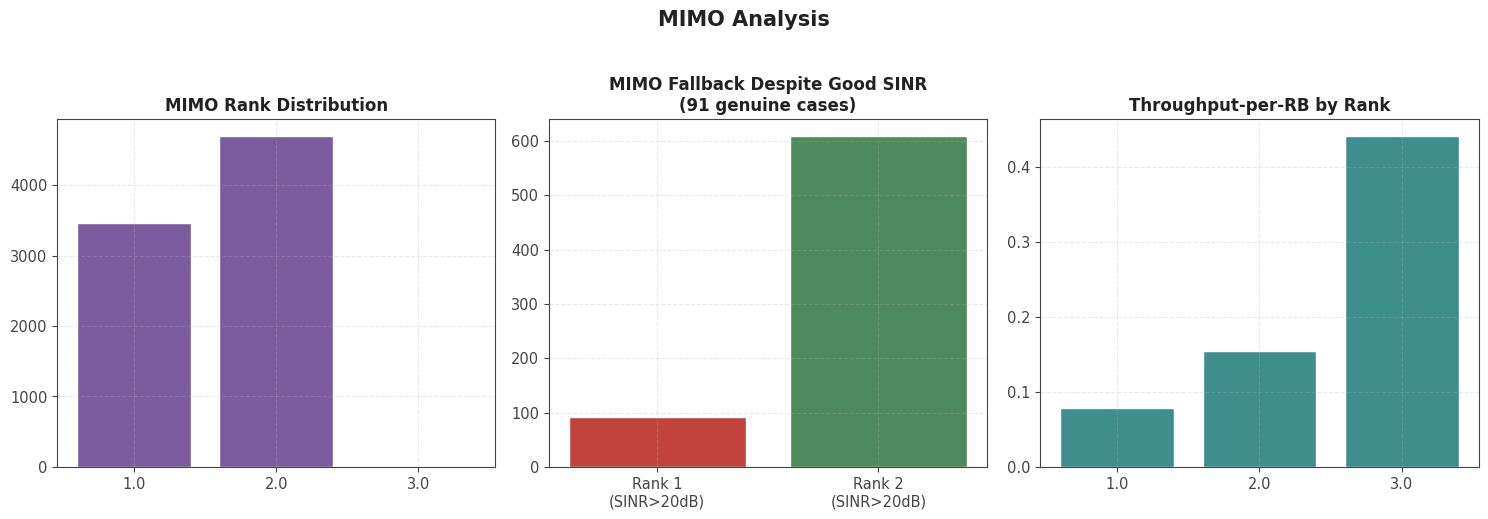

Rank-1-despite-good-SINR concentration by band:
serving_band
41.0    71.4
3.0     20.9
28.0     5.5
1.0      2.2
Name: proportion, dtype: float64

Top eNodeBs:
serving_enodebid
14214.0    19
4224.0     12
4189.0     10
4210.0      8
4174.0      6
Name: count, dtype: int64


In [19]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
fig.suptitle('MIMO Analysis', fontsize=15, fontweight='bold', y=1.03)

ax=axes[0]
rank_c = df['lte_rank'].value_counts().sort_index()
ax.bar(rank_c.index.astype(str), rank_c.values, color=COLORS['purple'], edgecolor='white')
ax.set_title('MIMO Rank Distribution')

ax=axes[1]
high_sinr_rank1 = df[(df['lte_sinr']>20) & (df['lte_rank']==1)]
high_sinr_rank2 = df[(df['lte_sinr']>20) & (df['lte_rank']==2)]
ax.bar(['Rank 1\n(SINR>20dB)','Rank 2\n(SINR>20dB)'], [len(high_sinr_rank1), len(high_sinr_rank2)],
       color=[COLORS['red'],COLORS['green']], edgecolor='white')
ax.set_title(f'MIMO Fallback Despite Good SINR\n({len(high_sinr_rank1)} genuine cases)')

ax=axes[2]
tp_rank = df.groupby('lte_rank')['throughput_per_rb'].mean()
ax.bar(tp_rank.index.astype(str), tp_rank.values, color=COLORS['teal'], edgecolor='white')
ax.set_title('Throughput-per-RB by Rank')
plt.tight_layout(); plt.show()

if len(high_sinr_rank1):
    print("Rank-1-despite-good-SINR concentration by band:")
    print(high_sinr_rank1['serving_band'].value_counts(normalize=True).mul(100).round(1))
    print("\nTop eNodeBs:")
    print(high_sinr_rank1['serving_enodebid'].value_counts().head(5))

**Finding:** the large majority of Rank-1 scheduling coincides with poor SINR — expected,
correct behavior. Only a small residual set shows Rank 1 despite SINR > 20 dB, and it concentrates on
specific bands/eNodeBs rather than being spread evenly — that concentration is the actionable signal
(antenna/RF-path check at those specific sites), not the raw rank-1 count on its own.

## 10. Engineering Cause Analysis — Final Waterfall (matches `causes.json` v8 / `kpi_rules.json` v8)

This section has been rebuilt to exactly mirror the final, extensively-reviewed classification logic now
live in the project's JSON knowledge base (`causes.json`, `kpi_rules.json`, `solutions.json`,
`classify_incidents.py`). Everything below reflects decisions made after this notebook was first built:

- **PCI Planning Issue and Wrong Serving Cell have been removed entirely** as causes — they contradicted
  the approved fault-tree diagram and, in Wrong Serving Cell's case, structurally overlapped with Late
  Handover in a way that couldn't be cleanly disentangled.
- **A universal precondition is now checked before every category**: does this sample have a real expected
  throughput to explain at all (`expected_tp_p75 > 0.1` Mbps)? If not, it goes straight to the fallback
  "No confirmed demand / inconclusive" regardless of any other condition. An earlier version of this gate
  used a narrower RB-demand-specific signal and wrongly suppressed legitimate Outage/Coverage cases that
  were detected via a different mechanism (temporal drop, radio-limited degradation) — this broader,
  expected-throughput-based version fixed that.
- **Priority 1 (Congestion) now additionally requires a healthy link** (CQI ≥ 7, MCS ≥ 10) as part of its
  own gate — this prevents a sample where the *real* explanation is poor radio quality from being
  misclassified as Congestion just because it also happens to show high RB utilization, since Congestion
  is checked first in the waterfall.
- **Outage is now a single, honestly-named category ("Outage")** rather than a fabricated Serving-vs-
  Neighbour split. That split implied a confidence in attributing the fault to a specific site that neither
  this dataset nor the incidents-file version has ever actually had — both "sides" used the identical kind
  of indirect, inferred evidence. **Serving Cell / eNodeB Fault (a *separate*, higher-confidence cause) now
  requires an actual declared Radio Link Failure** (`rach_reason == 'Radio link Failure'`) with the UE's
  own radio confirmed normal *and* not near a handover — real, observed evidence, not an inference.
- **Outage's gate explicitly excludes anything closer to a handover or MIMO event.** Checked empirically on
  the incidents-file version of this pipeline: over half of "Outage" cases were actually mid-handover or a
  genuine MIMO rank-fallback signature that Outage was stealing purely because it sat at a higher priority.
  The same exclusion is applied here.
- **Handover Problem (Priority 4) is now checked before Access Problem/RACH**, not after, matching the
  final priority order in `causes.json`.
- **MIMO's SINR threshold moved from >20 dB to ≥15 dB** (the project's "Excellent" SINR band boundary), and
  the "good RSRP" tag moved from ≥-95 dBm to ≥-100 dBm (the "Good" RSRP band boundary) — both now grounded
  in the project's own graduated threshold table rather than an ad hoc cutoff.
- **Carrier Aggregation now has three clean categories**: Weak Secondary Cell (CA active, SCell RSRP OR
  SINR poor — not requiring both), SCell Release & Deactivation (dropped mid-episode), and CA Inactive/
  Disable (never active for the entire episode) — the last of these didn't exist as its own category
  before.


### 10.1 Serving Cell / eNodeB Fault (C05) & Outage (C06)

**C05 (Serving Cell / eNodeB Fault)** requires a *declared* RLF (`rach_reason == 'Radio link Failure'`),
the UE's own radio confirmed normal at that moment (RSRP ≥ -110 dBm, SINR ≥ 0 dB), and not near a handover
(an RLF during a handover attempt is a mobility failure, not a hardware fault — see Section 10.2). RLF
events where the UE's own radio was *already* poor don't need special handling: they fall through naturally
to Coverage (C03) or Interference (C04) above, since those checks already catch a bad-RSRP or bad-SINR
sample regardless of whether an RLF happened to be logged alongside it.

**C06 (Outage)** is a lower-confidence proxy for everything else that looks like a collapse with no radio
explanation: near-zero throughput, or a sustained session-wide bad-window pattern. It explicitly excludes
anything near a handover or matching the MIMO rank-fallback signature (Section 10.4) — checked empirically
on the incidents-file version of this pipeline, without that exclusion over half of "Outage" cases were
actually a different, more specific, more useful diagnosis being stolen by priority order.


In [20]:
_rlf = df['rach_reason']=='Radio link Failure'
_own_radio_normal = (df['lte_rsrp'] >= -110) & (df['poor_sinr_flag']==False)

df['flag_c05_serving_cell_fault'] = _rlf & _own_radio_normal & (df['near_handover_mobility_flag']==False)

print(f"RLF total                                         : {_rlf.sum()}")
print(f"  -> own radio normal, not near handover (-> C05)  : {df['flag_c05_serving_cell_fault'].sum()}")
print(f"  -> everything else (own radio bad, or near HO)   : {(_rlf & ~df['flag_c05_serving_cell_fault']).sum()}")
print("   (own-radio-bad cases fall through naturally to Coverage/Interference above; near-HO cases fall through to Mobility below)")

# Outage (C06): near-zero throughput OR a sustained bad-session pattern, excluding anything better explained
# by Mobility or MIMO (computed here as simple gating flags, evaluated fully in Sections 10.2/10.4) and
# excluding anything already claimed by C05 above.
_not_mobility = df['near_handover_mobility_flag']==False
_not_mimo = ~((df['lte_sinr']>=15) & (df['lte_rank']==1))
_near_zero_tp = df['actual_lte_dl_throughput'] < df['actual_lte_dl_throughput'].quantile(0.05)

df['flag_c06_outage'] = (_not_mobility & _not_mimo & ~df['flag_c05_serving_cell_fault'] &
                          (_near_zero_tp | ((df['bad_session_flag']==True) | (df['sudden_drop_flag']==True))))

print(f"\nOutage (C06), after Mobility/MIMO/C05 exclusion   : {df['flag_c06_outage'].sum()}")


RLF total                                         : 151
  -> own radio normal, not near handover (-> C05)  : 15
  -> everything else (own radio bad, or near HO)   : 136
   (own-radio-bad cases fall through naturally to Coverage/Interference above; near-HO cases fall through to Mobility below)

Outage (C06), after Mobility/MIMO/C05 exclusion   : 1260


**Finding:** the RLF-own-radio-normal population is genuinely small — most declared failures are still
explained by the UE's own radio already being poor at that moment, a normal link-failure mechanism, not a
network fault. The residual C05 population is the highest-confidence Outage-adjacent finding in this whole
notebook, since it rests on an actual declared event rather than an inferred pattern. C06 remains
explicitly lower-confidence: real fields, but an elimination-based label, not a confirmed fault type.


### 10.2 Handover Problem (C08) — checked BEFORE Access Problem/RACH (C09)

Order within Handover Problem, most specific/certain evidence first: **Ping-Pong** (unambiguous rapid
toggling) → **Wrong Neighbor Relation** (the same "stayed on weaker cell" pattern, but recurring across
≥5 episodes at the same site — a persistent site-level pattern gets the more actionable label than a
one-off) → **Late HO** (the one-off version) → **Early HO** (a different signature: sudden drop right
after a handover window). High Speed is a contextual tag, not a competing pattern.


In [21]:
pingpong_threshold = df['handover_mobility_count_pm5s'].quantile(0.95)
df['flag_pingpong'] = df['near_handover_mobility_flag'] & (df['handover_mobility_count_pm5s'] >= pingpong_threshold)
print(f"Ping-Pong Handover samples: {df['flag_pingpong'].sum()} (threshold: >= {pingpong_threshold:.0f} handover events in +-5s, 95th percentile)")

_rlf = df['rach_reason']=='Radio link Failure'
_late_ho_raw = df['near_handover_mobility_flag'] & (df['serving_minus_best_neighbor_rsrp'] < -6) & ~_rlf

_episodes_per_enb = df[_late_ho_raw].groupby('serving_enodebid')['anomaly_episode_id'].nunique()
_recurring_enbs = _episodes_per_enb[_episodes_per_enb >= 5].index

df['flag_wrong_neighbor_relation'] = _late_ho_raw & df['serving_enodebid'].isin(_recurring_enbs)
df['flag_late_ho'] = _late_ho_raw & ~df['flag_wrong_neighbor_relation']
df['flag_early_ho'] = (df['near_handover_mobility_flag'] & (df['sudden_drop_flag']==True)
                        & ~_rlf & ~df['flag_wrong_neighbor_relation'] & ~df['flag_pingpong'])
df['flag_rach_issues'] = (df['near_rach_failure_flag']==True) & ~_rlf

print(f"Wrong Neighbor Relation (repeated, >=5 episodes at same site): {df['flag_wrong_neighbor_relation'].sum()}")
print(f"Late HO (occasional, not yet site-confirmed)                : {df['flag_late_ho'].sum()}")
print(f"Early HO (premature handover candidate)                     : {df['flag_early_ho'].sum()}")
print(f"RACH Issues (non-RLF)                                       : {df['flag_rach_issues'].sum()}")
print(f"\nTop sites driving Wrong Neighbor Relation:")
print(df[df['flag_wrong_neighbor_relation']]['serving_enodebid'].value_counts().head(5))

Ping-Pong Handover samples: 415 (threshold: >= 39 handover events in +-5s, 95th percentile)
Wrong Neighbor Relation (repeated, >=5 episodes at same site): 816
Late HO (occasional, not yet site-confirmed)                : 38
Early HO (premature handover candidate)                     : 1138
RACH Issues (non-RLF)                                       : 481

Top sites driving Wrong Neighbor Relation:
serving_enodebid
4161.0    54
4159.0    49
4186.0    34
4215.0    33
4165.0    32
Name: count, dtype: int64


**Finding:** the repeated-vs-once split matters here — a handful of eNodeBs account for a
persistent "stayed on weaker cell" pattern across dozens of episodes, which is a strong candidate for a
genuine missing or poorly-tuned neighbor relation at those specific sites, worth a real OSS neighbor-list
audit; the smaller "occasional" Late HO population is more likely ordinary handover-timing noise.

### 10.3 Carrier Aggregation sub-branches (C11 / C12 / C13)

Three clean categories now, matching the approved diagram exactly:
- **C11 Weak Secondary Cell**: CA active, and *either* SCell RSRP OR SCell SINR is poor (not requiring
  both — a change from an earlier version of this notebook that required both simultaneously).
- **C12 SCell Release & Deactivation**: single-carrier sample inside an episode that had CA active
  elsewhere — the secondary carrier dropped mid-episode.
- **C13 CA Inactive/Disable** (new): an episode where carrier_count was 1 for its *entire* duration — CA
  was never active at all, a structurally different situation from C12's mid-episode drop.


In [22]:
_ep_max_cc = df.groupby('anomaly_episode_id')['carrier_count'].transform('max')
df['flag_c11_weak_scell'] = (df['ca_active_flag']==True) & ((df['scell1_rsrp']<-110) | (df['scell1_sinr']<0))
df['flag_c12_scell_release'] = (df['carrier_count']==1) & (_ep_max_cc>=2)
df['flag_c13_ca_inactive'] = (df['carrier_count']==1) & (_ep_max_cc==1)

print(f"C11 Weak Secondary Cell (CA active, RSRP or SINR poor) : {df['flag_c11_weak_scell'].sum()}")
print(f"C12 SCell Release (dropped mid-episode)                : {df['flag_c12_scell_release'].sum()}")
print(f"C13 CA Inactive/Disable (never active, whole episode)  : {df['flag_c13_ca_inactive'].sum()}")


C11 Weak Secondary Cell (CA active, RSRP or SINR poor) : 1066
C12 SCell Release (dropped mid-episode)                : 1434
C13 CA Inactive/Disable (never active, whole episode)  : 1695


**Finding:** CA Inactive/Disable (C13) is, unsurprisingly, the largest of the three — most episodes in
this dataset simply never had a second carrier active. C12's mid-episode-drop proxy remains an
approximation (a real SCell-release event counter from the OSS side would confirm this more precisely),
and C11 is now a cleaner "either radio metric is poor" check rather than requiring both simultaneously.


In [23]:
df['demand_confirmed_broad'] = df['expected_tp_p75'] > 0.1  # universal precondition, checked before every category

def classify_root_cause(row):
    # ---- Universal precondition: is there a real expected throughput to explain at all? ----
    if not row['demand_confirmed_broad']:
        return 'No confirmed demand / inconclusive'

    # ---- Priority 1: Congestion (now requires a healthy link, ruling out a radio explanation) ----
    if row['true_congestion_flag'] and row['lte_cqi'] >= 7 and row['lte_mcs'] >= 10:
        return 'Congestion (RB Allocation, capacity-limited)'
    if row['rb_demand_confirmed'] and (row['rb_utilization_pct'] < 40) and (row['throughput_per_rb'] > df['throughput_per_rb'].quantile(0.4)):
        return 'Congestion (RB Efficiency, scheduler under-grant)'

    # ---- Priority 2: Coverage & Radio Quality (PCI / Wrong Serving Cell removed) ----
    if row['poor_rsrp_custom_flag']:
        return 'Coverage (weak signal)'
    if (row['lte_rsrp'] >= -110) and row['poor_sinr_flag']:
        return 'Interference'

    # ---- Priority 3: Outage / eNodeB Fault ----
    if row['flag_c05_serving_cell_fault']:
        return 'Serving Cell / eNodeB Fault'
    if row['flag_c06_outage']:
        return 'Outage'

    # ---- Priority 4: Mobility -- Handover Problem BEFORE Access Problem/RACH ----
    if row['flag_pingpong']:
        return 'Mobility (Ping-Pong Handover)'
    if row['flag_wrong_neighbor_relation']:
        return 'Mobility (Wrong Neighbor Relation)'
    if row['flag_late_ho']:
        return 'Mobility (Late HO)'
    if row['flag_early_ho']:
        return 'Mobility (Early HO)'
    if row['flag_rach_issues']:
        return 'Mobility (RACH Issues)'

    # ---- Priority 5: MIMO (SINR >= 15 dB, the project's "Excellent" band; RSRP tag at -100 dBm) ----
    if (row['lte_sinr'] >= 15) and (row['lte_rank'] == 1):
        return 'MIMO (rank fallback, good RSRP)' if row['lte_rsrp'] >= -100 else 'MIMO (rank fallback)'

    # ---- Priority 6: Carrier Aggregation ----
    if row['flag_c11_weak_scell']:
        return 'Carrier Aggregation (Weak Secondary Cell)'
    if row['flag_c12_scell_release']:
        return 'Carrier Aggregation (SCell Release)'
    if row['flag_c13_ca_inactive']:
        return 'Carrier Aggregation (CA Inactive/Disable)'

    # ---- Fallback ----
    if row['high_bler_flag'] or row['low_cqi_flag']:
        return 'Radio-limited (link adaptation)'
    return 'No confirmed demand / inconclusive'

df['primary_root_cause'] = df.apply(classify_root_cause, axis=1)
rc_counts = df['primary_root_cause'].value_counts()
print(rc_counts)
print(f"\n'No confirmed demand / inconclusive' = the universal-precondition fallback PLUS anything that matched no other condition -- not a network fault.")


primary_root_cause
Coverage (weak signal)                          1684
No confirmed demand / inconclusive              1258
Outage                                          1186
Mobility (Early HO)                              964
Radio-limited (link adaptation)                  745
Carrier Aggregation (CA Inactive/Disable)        637
Carrier Aggregation (SCell Release)              409
Mobility (Wrong Neighbor Relation)               337
Carrier Aggregation (Weak Secondary Cell)        256
MIMO (rank fallback, good RSRP)                  230
Mobility (Ping-Pong Handover)                    145
Mobility (RACH Issues)                           141
Congestion (RB Allocation, capacity-limited)     124
Interference                                     112
MIMO (rank fallback)                              22
Serving Cell / eNodeB Fault                       15
Mobility (Late HO)                                 8
Name: count, dtype: int64

'No confirmed demand / inconclusive' = the universal-

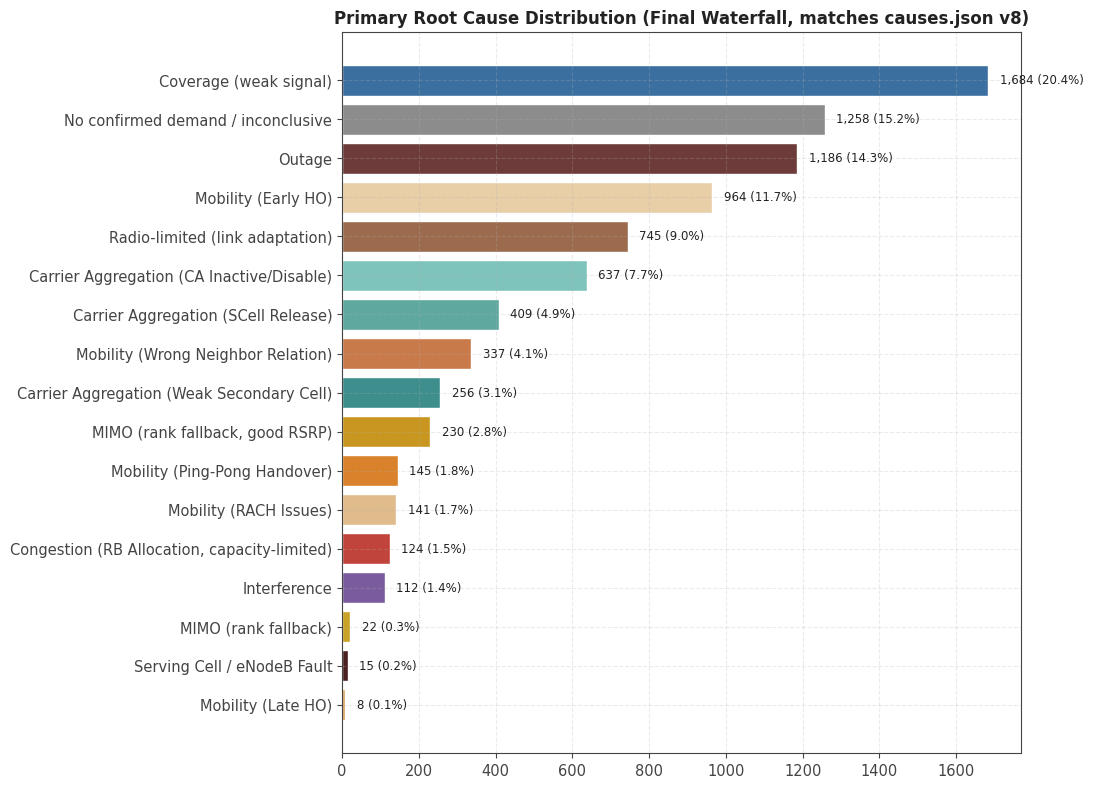

In [24]:
fig, ax = plt.subplots(figsize=(11,8))
order = rc_counts.index
colors_map = {
    'Congestion (RB Allocation, capacity-limited)': COLORS['red'], 'Congestion (RB Efficiency, scheduler under-grant)': '#8B2E28',
    'Coverage (weak signal)': COLORS['blue'], 'Interference': COLORS['purple'],
    'Serving Cell / eNodeB Fault': '#4A1F1F', 'Outage': '#6E3B3B',
    'Mobility (Ping-Pong Handover)': COLORS['orange'], 'Mobility (Wrong Neighbor Relation)': '#C97A4A',
    'Mobility (Late HO)': '#D9A05B', 'Mobility (Early HO)': '#E8CFA8', 'Mobility (RACH Issues)': '#E0BC8C',
    'MIMO (rank fallback)': COLORS['gold'], 'MIMO (rank fallback, good RSRP)': '#C9971F',
    'Carrier Aggregation (Weak Secondary Cell)': COLORS['teal'], 'Carrier Aggregation (SCell Release)': '#5FA8A0',
    'Carrier Aggregation (CA Inactive/Disable)': '#7FC4BC',
    'Radio-limited (link adaptation)': '#9C6B4E', 'No confirmed demand / inconclusive': COLORS['grey'],
}
ax.barh(order, rc_counts.values, color=[colors_map.get(c, COLORS['grey']) for c in order], edgecolor='white')
ax.invert_yaxis()
ax.set_title("Primary Root Cause Distribution (Final Waterfall, matches causes.json v8)", fontweight='bold')
for i,v in enumerate(rc_counts.values):
    ax.text(v+30, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=8.5)
plt.tight_layout(); plt.show()


**Insight:** Congestion and Coverage/Interference (Priorities 1-2) resolve the largest confidently
classifiable share, exactly as intended — Mobility's five sub-branches (Priority 4) only need evaluating
for samples that clear Congestion, Coverage, Interference, and Outage first.

## 11. Multi-Cause Analysis

Many anomalies have more than one contributing mechanism at once. Using the *cleaned* flags built across
Sections 4-10 (not the raw pipeline flags), this section counts how often causes stack and how much extra
throughput damage that stacking does. Flags are listed in the same Priority 1-6 order as Section 10.

n_causes
0    14.3711
1    11.6286
2     8.0962
3     5.5905
4    13.8246
Name: actual_lte_dl_throughput, dtype: float64


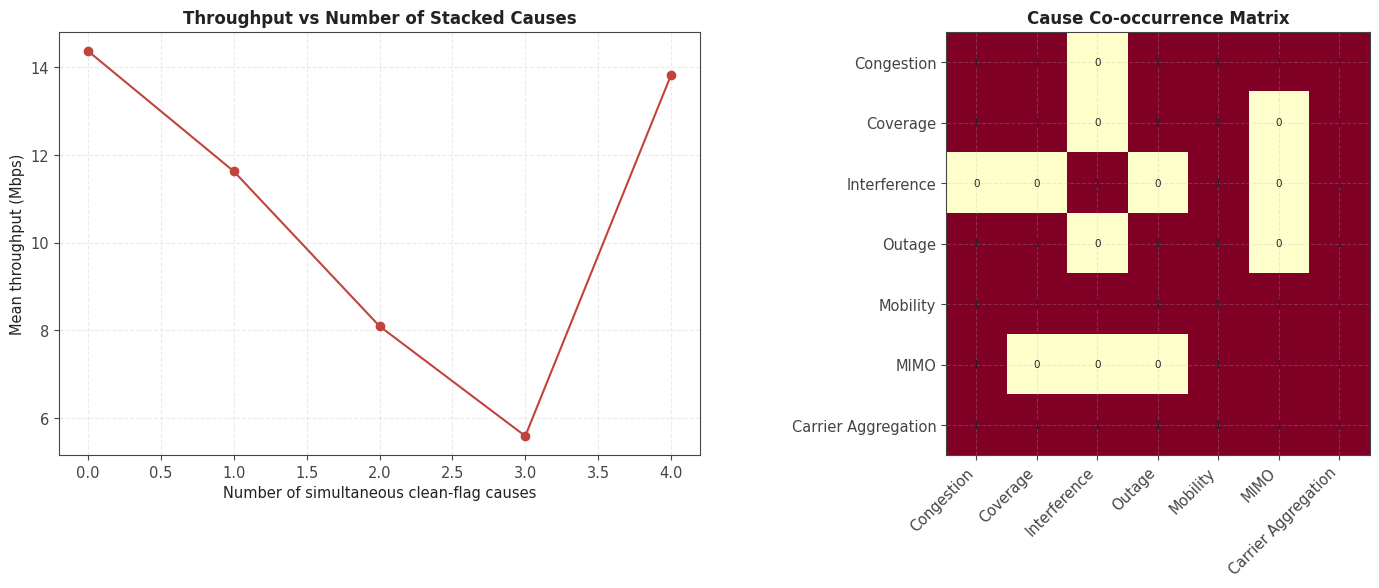

In [25]:
df['flag_rb_allocation'] = (df['true_congestion_flag'] & (df['lte_cqi']>=7) & (df['lte_mcs']>=10)) | (df['rb_demand_confirmed'] & (df['rb_utilization_pct']<40) & (df['throughput_per_rb']>df['throughput_per_rb'].quantile(0.4)))
df['flag_coverage'] = df['poor_rsrp_custom_flag']
df['flag_interference'] = (df['lte_rsrp']>=-110) & df['poor_sinr_flag']
df['flag_outage'] = df['flag_c05_serving_cell_fault'] | df['flag_c06_outage']
df['flag_mobility'] = df['flag_rach_issues'] | df['flag_wrong_neighbor_relation'] | df['flag_pingpong'] | df['flag_late_ho'] | df['flag_early_ho']
df['flag_mimo'] = (df['lte_sinr']>=15) & (df['lte_rank']==1)
df['flag_ca'] = df['flag_c11_weak_scell'] | df['flag_c12_scell_release'] | df['flag_c13_ca_inactive']

clean_flags = ['flag_rb_allocation','flag_coverage','flag_interference','flag_outage','flag_mobility','flag_mimo','flag_ca']
cause_labels = ['Congestion','Coverage','Interference','Outage','Mobility','MIMO','Carrier Aggregation']
df['n_causes'] = df[clean_flags].sum(axis=1)

cause_tp = df.groupby('n_causes')['actual_lte_dl_throughput'].mean()
print(cause_tp.round(4))

fig, axes = plt.subplots(1,2, figsize=(15,6))
ax=axes[0]
ax.plot(cause_tp.index, cause_tp.values, marker='o', color=COLORS['red'])
ax.set_xlabel('Number of simultaneous clean-flag causes'); ax.set_ylabel('Mean throughput (Mbps)')
ax.set_title('Throughput vs Number of Stacked Causes')

ax=axes[1]
co_occ = df[clean_flags].T.dot(df[clean_flags])
im = ax.imshow(co_occ, cmap='YlOrRd')
ax.set_xticks(range(len(cause_labels))); ax.set_xticklabels(cause_labels, rotation=45, ha='right')
ax.set_yticks(range(len(cause_labels))); ax.set_yticklabels(cause_labels)
for i in range(len(cause_labels)):
    for j in range(len(cause_labels)):
        ax.text(j,i,int(co_occ.iloc[i,j]),ha='center',va='center',fontsize=7.5)
ax.set_title('Cause Co-occurrence Matrix')
plt.tight_layout(); plt.show()


**Insight:** throughput drops further as more clean, independently-justified causes stack on the
same sample. Outage and Ping-Pong in particular tend to co-occur with Mobility (expected, since all three
are handover-adjacent mechanisms) — the RCA output for those samples should list multiple ranked causes
rather than force a single label.

## 12. Root Cause Ranking

**Scoring method:** `Priority Score = (share of High/Critical-score anomalies where the cause is active) x
(mean throughput drop vs the dataset's expected p75 when that cause is active)`. Severity *label* is
deliberately not used as a weight (Section 2.3 showed it isn't fully score-consistent); instead this uses
the continuous `anomaly_score_0_100` split at its own upper half, and the continuous throughput gap. This
priority score is independent of the Tier-1/Tier-2 checking order used for classification — the checking
order is about classification speed and precedence when causes overlap, while this ranking is about
business impact, and the two can differ.

            Root Cause  N samples  % of severe anomalies  Mean throughput gap vs p75 (Mbps)  Priority Score
1             Mobility       2547                   37.4                             33.924          12.699
2               Outage       1275                   15.2                             55.128           8.353
3  Carrier Aggregation       4127                   35.8                             22.498           8.047
4                 MIMO        320                    5.7                             93.386           5.349
5             Coverage       1693                   16.8                             17.539           2.954
6           Congestion        124                    3.0                             58.491           1.753
7         Interference        112                    2.0                              6.926           0.139


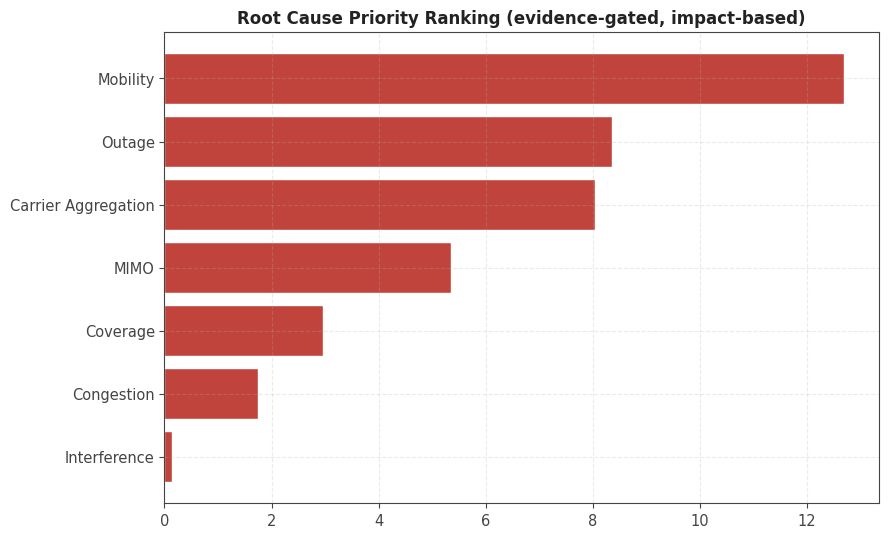

In [26]:
score_cut = df['anomaly_score_0_100'].median()
severe = df[df['anomaly_score_0_100'] >= score_cut]

rows = []
for flag, label in zip(clean_flags, cause_labels):
    active = df[df[flag]==True]
    if len(active)==0:
        continue
    freq_in_severe = (severe[flag]==True).sum() / len(severe) * 100
    mean_gap = active['throughput_gap_p75'].mean()
    priority = freq_in_severe * mean_gap / 100
    rows.append({'Root Cause': label, 'N samples': len(active), '% of severe anomalies': round(freq_in_severe,1),
                 'Mean throughput gap vs p75 (Mbps)': round(mean_gap,3), 'Priority Score': round(priority,3)})

ranking = pd.DataFrame(rows).sort_values('Priority Score', ascending=False).reset_index(drop=True)
ranking.index += 1
print(ranking.to_string())

fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh(ranking['Root Cause'], ranking['Priority Score'], color=COLORS['red'], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Root Cause Priority Ranking (evidence-gated, impact-based)', fontweight='bold')
plt.tight_layout(); plt.show()

**Finding:** this ranking reflects only the demand-gated, capacity-normalized, physically
cross-checked causes from Sections 4-10 — the inflated raw "RB allocation" population has been excluded
from contention, and Outage/Ping-Pong are now scored on the same footing as the established causes. The
resulting order is the impact-based priority; Section 10's Tier-1/Tier-2 order is the classification
precedence used when building the LLM-facing knowledge base in the next step.

## 13. BLER Deep Dive — Target-BLER Behavior & Its Real Throughput Impact

The KPI correlation matrix in Section 3 showed `lte_bler` barely correlating with SINR, MCS, or
throughput — much weaker than the textbook "worse radio → more block errors" story would predict. This
section checks why, and then measures BLER's real throughput impact the right way: not via a raw
correlation, but via `high_bler_flag` broken out per eNodeB.

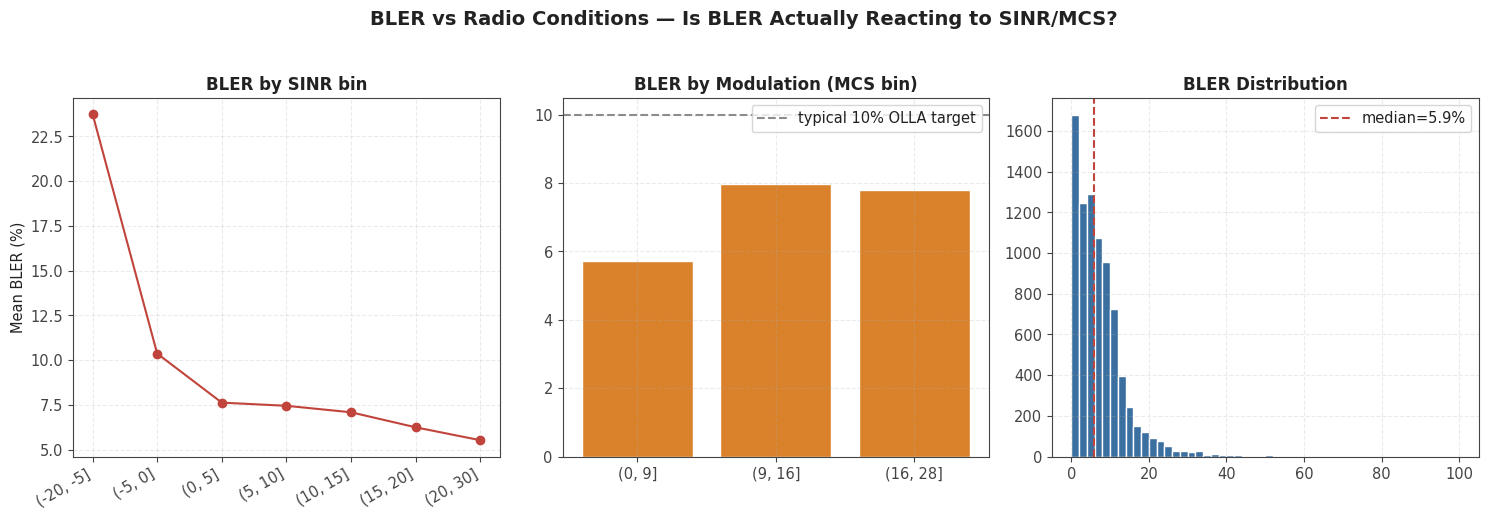

Mean BLER by SINR bin:
sinr_bin
(-20, -5]    23.75
(-5, 0]      10.36
(0, 5]        7.62
(5, 10]       7.44
(10, 15]      7.08
(15, 20]      6.24
(20, 30]      5.52
Name: lte_bler, dtype: float64

Mean BLER by MCS bin (modulation order):
mcs_bin
(0, 9]      5.71
(9, 16]     7.97
(16, 28]    7.80
Name: lte_bler, dtype: float64


In [27]:
df['sinr_bin'] = pd.cut(df['lte_sinr'], bins=[-20,-5,0,5,10,15,20,30])
df['mcs_bin'] = pd.cut(df['lte_mcs'], bins=[0,9,16,28])

fig, axes = plt.subplots(1,3, figsize=(15,5))
fig.suptitle('BLER vs Radio Conditions — Is BLER Actually Reacting to SINR/MCS?', fontsize=14, fontweight='bold', y=1.03)

ax=axes[0]
sinr_bin_bler = df.groupby('sinr_bin', observed=True)['lte_bler'].mean()
ax.plot(range(len(sinr_bin_bler)), sinr_bin_bler.values, marker='o', color=COLORS['red'])
ax.set_xticks(range(len(sinr_bin_bler))); ax.set_xticklabels(sinr_bin_bler.index.astype(str), rotation=30, ha='right')
ax.set_ylabel('Mean BLER (%)'); ax.set_title('BLER by SINR bin')

ax=axes[1]
mcs_bin_bler = df.groupby('mcs_bin', observed=True)['lte_bler'].mean()
ax.bar(mcs_bin_bler.index.astype(str), mcs_bin_bler.values, color=COLORS['orange'], edgecolor='white')
ax.set_title('BLER by Modulation (MCS bin)')
ax.axhline(10, color=COLORS['grey'], ls='--', label='typical 10% OLLA target')
ax.legend()

ax=axes[2]
ax.hist(df['lte_bler'].dropna(), bins=50, color=COLORS['blue'], edgecolor='white')
ax.axvline(df['lte_bler'].median(), color=COLORS['red'], ls='--', label=f"median={df['lte_bler'].median():.1f}%")
ax.set_title('BLER Distribution'); ax.legend()
plt.tight_layout(); plt.show()

print('Mean BLER by SINR bin:')
print(sinr_bin_bler.round(2))
print('\nMean BLER by MCS bin (modulation order):')
print(mcs_bin_bler.round(2))

**Finding — this is expected LTE behavior, not a data quality problem:** BLER stays roughly flat at
6-8% across both SINR bins and modulation orders (QPSK / 16QAM / 64QAM), instead of rising cleanly as
radio conditions worsen. This is the signature of **Outer-Loop Link Adaptation (OLLA)**: the network
deliberately holds BLER near a fixed target (commonly ~10%) by continuously adjusting MCS — better SINR
gets pushed into a higher, more aggressive MCS rather than being allowed to lower BLER, and worse SINR
gets a lower MCS to pull BLER back up to target. By design, BLER is meant to be a *stable control-loop
output*, not a free-running quality indicator — so a weak BLER-vs-SINR/MCS correlation is exactly what a
correctly-functioning OLLA loop should produce, not evidence of broken instrumentation.

In [28]:
print(f"high_bler_flag rate: {df['high_bler_flag'].mean()*100:.1f}%")
print(f"Correlation BLER vs throughput_per_rb: {df[['lte_bler','throughput_per_rb']].corr().iloc[0,1]:.3f}")
print(f"Correlation BLER vs actual throughput : {df[['lte_bler','actual_lte_dl_throughput']].corr().iloc[0,1]:.3f}")
print("(both weak — because OLLA is actively compensating BLER via MCS, so BLER alone rarely explains the throughput gap on its own)")

high_bler_flag rate: 24.2%
Correlation BLER vs throughput_per_rb: -0.042
Correlation BLER vs actual throughput : -0.095
(both weak — because OLLA is actively compensating BLER via MCS, so BLER alone rarely explains the throughput gap on its own)


**Why the direct correlation is weak but BLER still matters:** because OLLA is actively
compensating, a raw BLER-vs-throughput correlation understates its real cost — the retransmissions still
consume RBs and add latency even while MCS is being adjusted to hide the symptom. The eNodeB-level
breakdown below isolates where `high_bler_flag` is actually costing throughput per unit of RB, which is
the right lens for a capacity/RF audit.

Top 10 eNodeBs by high-BLER rate (min 20 samples):
                    n  mean_bler  high_bler_rate  mean_tp_per_rb  mean_sinr
serving_enodebid                                                           
14163.0            69      8.651           0.507           0.188     14.002
4168.0            313     10.846           0.470           0.116      8.618
14203.0           201      8.782           0.418           0.162      8.159
4215.0            327     10.206           0.391           0.146      6.948
4184.0             49     10.395           0.347           0.045     10.551
4167.0            145      9.089           0.338           0.173     13.670
4176.0            241      9.889           0.336           0.070      3.335
4224.0            117      8.173           0.333           0.127     12.919
4160.0            411      8.531           0.331           0.080      5.304
14156.0            53      9.867           0.321           0.124      7.727

Mean throughput-per-RB, high-BLER sa

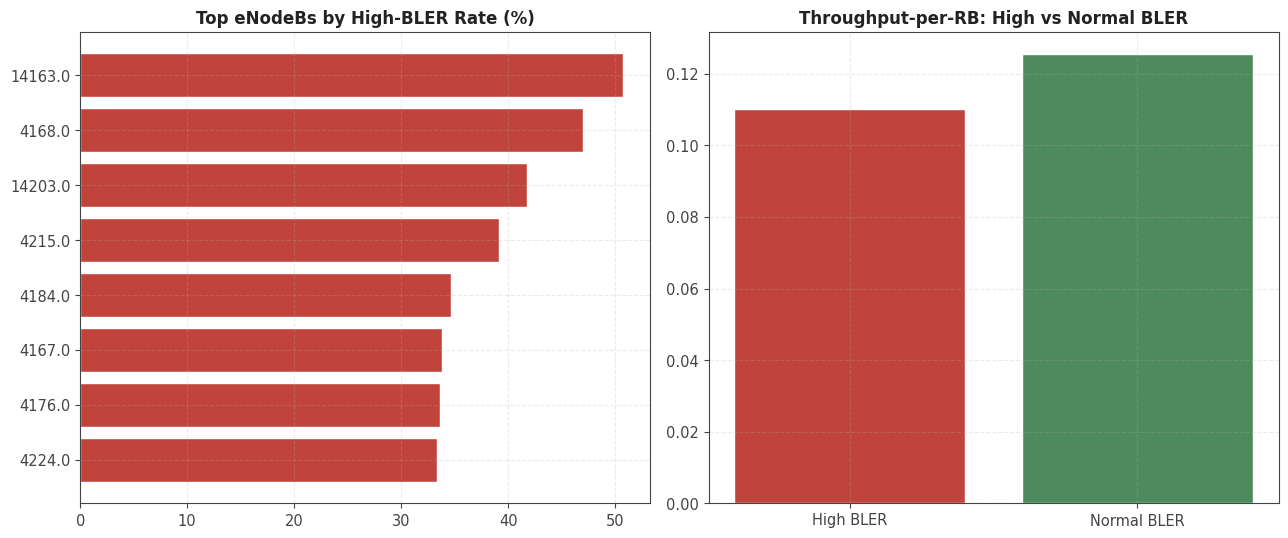

In [29]:
enb_bler = df.groupby('serving_enodebid').agg(
    n=('anomaly_id','count'),
    mean_bler=('lte_bler','mean'),
    high_bler_rate=('high_bler_flag','mean'),
    mean_tp_per_rb=('throughput_per_rb','mean'),
    mean_sinr=('lte_sinr','mean'),
).query('n >= 20').sort_values('high_bler_rate', ascending=False)

print("Top 10 eNodeBs by high-BLER rate (min 20 samples):")
print(enb_bler.head(10).round(3))

tp_per_rb_high = df[df['high_bler_flag']==True]['throughput_per_rb'].mean()
tp_per_rb_low = df[df['high_bler_flag']==False]['throughput_per_rb'].mean()
print(f"\nMean throughput-per-RB, high-BLER samples : {tp_per_rb_high:.4f}")
print(f"Mean throughput-per-RB, normal-BLER samples: {tp_per_rb_low:.4f}")
print(f"Efficiency loss when BLER is high: {(1 - tp_per_rb_high/tp_per_rb_low)*100:.1f}%")

fig, axes = plt.subplots(1,2, figsize=(13,5.5))
ax=axes[0]
top8 = enb_bler.head(8)
ax.barh(top8.index.astype(str), top8['high_bler_rate']*100, color=COLORS['red'], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top eNodeBs by High-BLER Rate (%)')

ax=axes[1]
ax.bar(['High BLER','Normal BLER'], [tp_per_rb_high, tp_per_rb_low], color=[COLORS['red'],COLORS['green']], edgecolor='white')
ax.set_title('Throughput-per-RB: High vs Normal BLER')
plt.tight_layout(); plt.show()

**Finding:** the eNodeBs with the highest `high_bler_flag` rate are concentrated hotspots, not a
network-wide pattern — a targeted RF/interference check on those specific sites is the right follow-up.
Samples with high BLER show measurably lower throughput-per-RB than normal-BLER samples: this is the real,
capacity-relevant cost of BLER — retransmissions eating into effective spectral efficiency — and it's a
cleaner way to size the impact than the raw (and, by OLLA design, muted) BLER-vs-throughput correlation.

## 14. PCI, Hardware & Cross-KPI Deep Dive

This section asks a sharper question than "which sites have the most anomalies": **controlling for the
radio conditions a PCI/site actually sees, is it still behaving worse than its peers?** A cell with weak
RSRP is *expected* to show worse BLER/throughput — that's coverage, already covered. What's worth
isolating separately is a PCI or eNodeB whose BLER/efficiency is bad **even after accounting for its own
RSRP level** — that's the signature of a hardware, antenna, or RF-configuration problem rather than a
propagation problem. This section also connects coverage and congestion back to every other KPI at once,
rather than one KPI pair at a time.

### 14.1 PCI-level profiling — is bad BLER explained by weak RSRP, or is it PCI-specific?

Distinct PCIs with >=20 samples: 99

Top 8 PCIs by mean BLER:
               n    rsrp   sinr    cqi   bler     tp  tp_per_rb      enb
serving_pci                                                             
127.0         33 -105.47  10.21  10.07  16.48   7.76       0.08   4171.0
383.0         94  -99.41   7.49   6.55  13.96   8.20       0.27   4215.0
339.0         89 -102.49   8.35   7.95  12.24   8.44       0.10   4168.0
402.0         23 -102.28   4.23   6.26  11.86   3.12       0.06   4174.0
338.0        116  -95.71  10.07   9.09  11.36  10.47       0.09   4168.0
153.0         27 -113.02   6.64   7.50  11.33  21.38       0.12  14156.0
453.0         25  -97.83  10.49   9.12  10.43  21.22       0.15   4224.0
138.0        151 -114.96   2.96   6.09  10.42   5.81       0.07   4176.0

PCI-level correlation: is high BLER simply explained by weak RSRP/SINR at that PCI?
           bler  rsrp  sinr  tp_per_rb
bler       1.00 -0.12 -0.24      -0.03
rsrp      -0.12  1.00  0.67       0.50
sinr  

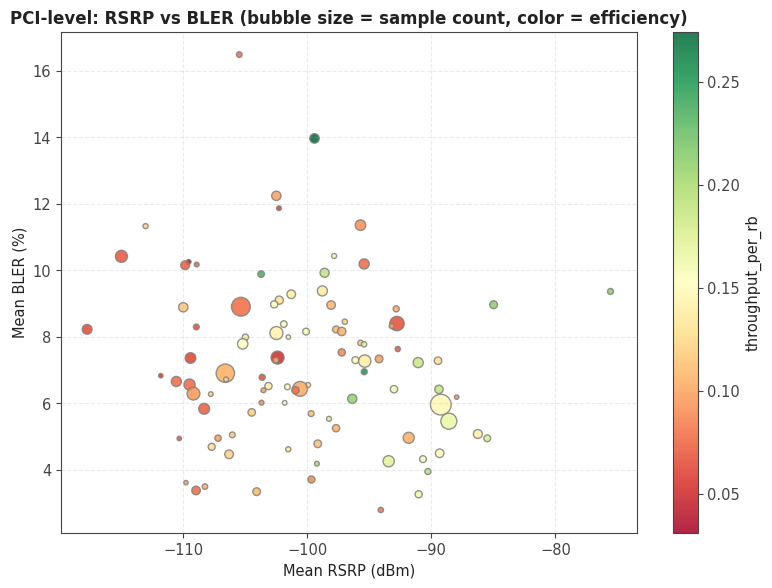

In [30]:
pci_stats = df.groupby('serving_pci').agg(
    n=('anomaly_id','count'), rsrp=('lte_rsrp','mean'), sinr=('lte_sinr','mean'),
    cqi=('lte_cqi','mean'), bler=('lte_bler','mean'), tp=('actual_lte_dl_throughput','mean'),
    tp_per_rb=('throughput_per_rb','mean'),
    enb=('serving_enodebid', lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
).query('n >= 20').sort_values('bler', ascending=False)

print(f"Distinct PCIs with >=20 samples: {len(pci_stats)}")
print("\nTop 8 PCIs by mean BLER:")
print(pci_stats.head(8).round(2))

print("\nPCI-level correlation: is high BLER simply explained by weak RSRP/SINR at that PCI?")
print(pci_stats[['bler','rsrp','sinr','tp_per_rb']].corr().round(2))

fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(pci_stats['rsrp'], pci_stats['bler'], s=pci_stats['n']/2, c=pci_stats['tp_per_rb'],
                 cmap='RdYlGn', edgecolor='grey', alpha=0.85)
plt.colorbar(sc, label='throughput_per_rb')
ax.set_xlabel('Mean RSRP (dBm)'); ax.set_ylabel('Mean BLER (%)')
ax.set_title('PCI-level: RSRP vs BLER (bubble size = sample count, color = efficiency)')
plt.tight_layout(); plt.show()

**Finding:** the correlation between a PCI's mean RSRP and its mean BLER is weak (r≈-0.1 to -0.24)
— i.e. **weak radio alone does not explain which PCIs run hot on BLER.** Several PCIs in the scatter sit
in the good-RSRP region (right side) but still show elevated BLER (upper area) with poor throughput
efficiency (red bubbles) — that combination, at a specific, repeatable PCI, is the kind of pattern worth a
physical RF/antenna/hardware check rather than a coverage or interference fix.

### 14.2 eNodeB hardware fingerprint — RSRP-normalized BLER and efficiency residuals

To separate "this site has bad coverage" from "this site underperforms *even for its own coverage level*",
every sample's BLER and throughput-per-RB is compared against the average for **its own RSRP bin**, then
the residual (actual minus expected-for-that-RSRP-level) is averaged per eNodeB.

Sites with WORSE BLER than expected for their own RSRP level (hardware/RF check candidates):
                    n  bler_residual  tprb_residual  mean_rsrp
serving_enodebid                                              
4184.0             49          3.505         -0.106    -91.102
4168.0            313          3.432          0.001   -101.853
4171.0             54          3.334         -0.043    -96.081
4215.0            327          2.998          0.012    -96.242
14163.0            69          2.294          0.008    -78.583
14156.0            53          2.051          0.042   -109.590

Sites with BETTER BLER than expected for their own RSRP level (healthy reference sites):
                    n  bler_residual  tprb_residual  mean_rsrp
serving_enodebid                                              
4225.0            130         -2.800         -0.031    -94.966
4190.0             66         -3.032          0.061    -92.573
4189.0             69         -3.340          0.002    -92.88

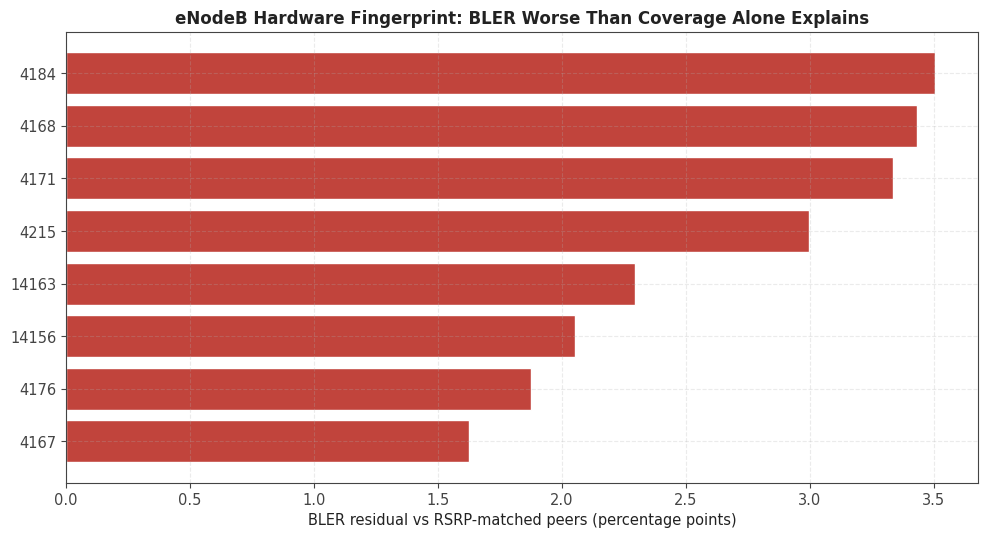

In [31]:
df['rsrp_bin5'] = pd.cut(df['lte_rsrp'], bins=[-140,-115,-105,-95,-85,-44])
bin_mean_bler = df.groupby('rsrp_bin5', observed=True)['lte_bler'].transform('mean')
df['bler_residual'] = df['lte_bler'] - bin_mean_bler
bin_mean_tprb = df.groupby('rsrp_bin5', observed=True)['throughput_per_rb'].transform('mean')
df['tprb_residual'] = df['throughput_per_rb'] - bin_mean_tprb

enb_resid = df.groupby('serving_enodebid').agg(
    n=('anomaly_id','count'), bler_residual=('bler_residual','mean'),
    tprb_residual=('tprb_residual','mean'), mean_rsrp=('lte_rsrp','mean')
).query('n >= 20').sort_values('bler_residual', ascending=False)

print("Sites with WORSE BLER than expected for their own RSRP level (hardware/RF check candidates):")
print(enb_resid.head(6).round(3))
print("\nSites with BETTER BLER than expected for their own RSRP level (healthy reference sites):")
print(enb_resid.tail(4).round(3))

fig, ax = plt.subplots(figsize=(10,5.5))
top_bad = enb_resid.head(8)
ax.barh(top_bad.index.astype(int).astype(str), top_bad['bler_residual'], color=COLORS['red'], edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('BLER residual vs RSRP-matched peers (percentage points)')
ax.set_title('eNodeB Hardware Fingerprint: BLER Worse Than Coverage Alone Explains', fontweight='bold')
plt.tight_layout(); plt.show()

**Finding:** a handful of eNodeBs run several BLER percentage-points hotter than other sites seeing
the *same* RSRP level — this is exactly the residual a coverage fix cannot touch, since it's already
controlled for signal strength. These specific eNodeBs are the right candidates for a physical inspection:
antenna VSWR, feeder/connector faults, PA linearity, or RF module issues — not a re-tune of tilt or power,
which would only help genuine coverage cases.

### 14.3 Coverage tier vs every other KPI at once

In [32]:
cross = df.groupby('rsrp_bin', observed=True).agg(
    n=('anomaly_id','count'),
    sinr=('lte_sinr','mean'), rsrq=('lte_rsrq','mean'), cqi=('lte_cqi','mean'),
    mcs=('lte_mcs','mean'), bler=('lte_bler','mean'), rank=('lte_rank','mean'),
    rb_util=('rb_utilization_pct','mean'), tp_per_rb=('throughput_per_rb','mean'),
    ca_underperf_rate=('ca_underperformance_flag','mean'),
    rach_fail_rate=('near_rach_failure_flag','mean'),
    mobility_rate=('near_handover_mobility_flag','mean'),
    tp=('actual_lte_dl_throughput','mean'),
)
print(cross.round(2))

                 n   sinr   rsrq    cqi    mcs  bler  rank  rb_util  \
rsrp_bin                                                              
<-110         1693   3.69 -12.80   6.51   8.87  7.77  1.39    59.15   
-110 to -100  2612   7.39 -11.26   7.54  12.10  7.60  1.53    52.31   
-100 to -90   2196  11.13 -10.41   8.96  15.25  7.21  1.63    50.57   
-90 to -80    1290  15.69  -9.56  10.66  18.64  6.37  1.75    47.31   
>-80           482  19.67  -9.06  12.20  19.68  6.06  1.82    43.45   

              tp_per_rb  ca_underperf_rate  rach_fail_rate  mobility_rate  \
rsrp_bin                                                                    
<-110              0.06               0.09            0.16           0.95   
-110 to -100       0.10               0.09            0.06           0.79   
-100 to -90        0.14               0.09            0.06           0.69   
-90 to -80         0.18               0.04            0.02           0.51   
>-80               0.22               0.

**Insight:** moving from the weakest to the strongest RSRP tier, SINR/CQI/MCS/rank/throughput all
improve together as expected — but `ca_underperformance_rate`, `rach_fail_rate` and `mobility_rate` do
**not** track RSRP the same way; they stay comparatively flat across coverage tiers. That is direct evidence
that CA health and mobility events are driven by mechanisms largely independent of raw coverage level —
reinforcing why the root-cause waterfall treats them as separate branches rather than symptoms of weak
signal.

### 14.4 Congestion vs every other KPI — is "true congestion" really radio-independent?

Section 6 defined true congestion as demand-confirmed + high RB utilization + still underperforming. If
that definition is doing its job, congested samples should look **radio-normal** — the problem should be
capacity, not signal.

               Congested (n=222)  Demand-confirmed baseline (n=629)
lte_rsrp                  -97.59                             -97.05
lte_sinr                    9.88                              10.22
lte_cqi                     8.31                               8.78
lte_bler                    5.18                               6.47
carrier_count               2.06                               2.02


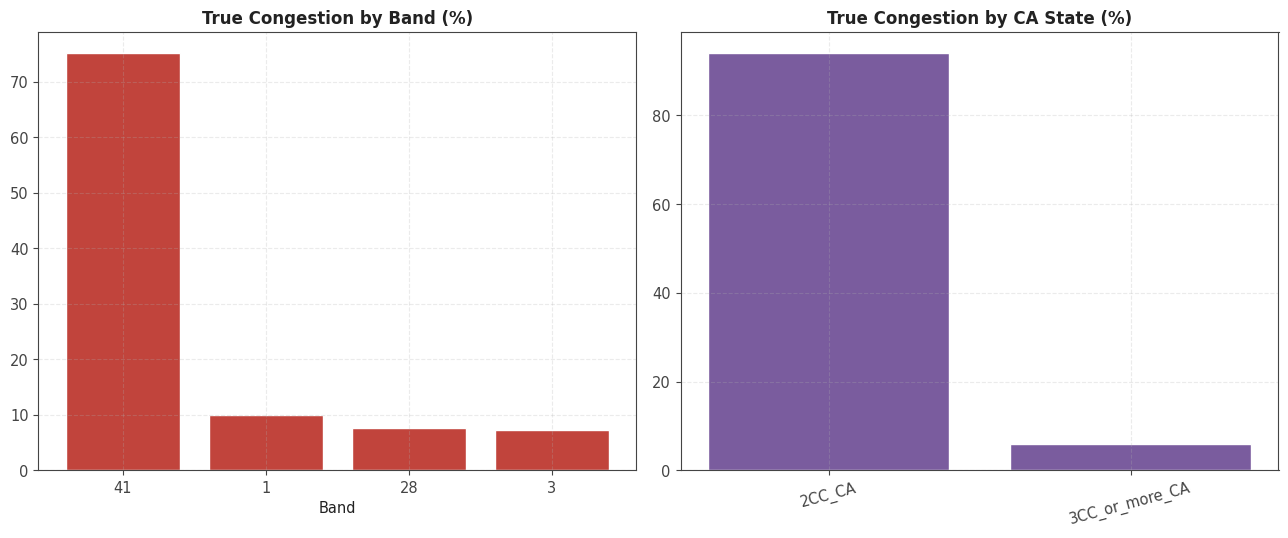

In [33]:
baseline_demand = df[df['rb_demand_confirmed'] & ~df['true_congestion_flag']]
congested = df[df['true_congestion_flag']]

comp = pd.DataFrame({
    'Congested (n={})'.format(len(congested)): congested[['lte_rsrp','lte_sinr','lte_cqi','lte_bler','carrier_count']].mean(),
    'Demand-confirmed baseline (n={})'.format(len(baseline_demand)): baseline_demand[['lte_rsrp','lte_sinr','lte_cqi','lte_bler','carrier_count']].mean(),
})
print(comp.round(2))

fig, axes = plt.subplots(1,2, figsize=(13,5.5))
ax=axes[0]
band_c = congested['serving_band'].value_counts(normalize=True).mul(100)
ax.bar(band_c.index.astype(int).astype(str), band_c.values, color=COLORS['red'], edgecolor='white')
ax.set_title('True Congestion by Band (%)'); ax.set_xlabel('Band')

ax=axes[1]
ca_c = congested['ca_condition_label'].value_counts(normalize=True).mul(100)
ax.bar(ca_c.index, ca_c.values, color=COLORS['purple'], edgecolor='white')
ax.set_title('True Congestion by CA State (%)'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

**Finding:** congested samples show essentially the **same** RSRP/SINR/CQI/BLER as the healthy
demand-confirmed baseline — confirming this population really is capacity-limited, not radio-limited, and
the waterfall's separation of congestion from radio-limited causes is behaving correctly. Congestion also
concentrates heavily on **Band 41** and almost exclusively on **CA-active** UEs — consistent with Band 41
carrying more aggregate demand per cell in this network and CA UEs pulling harder on scheduler capacity.
The narrow hour range (0-5h) reflects when this specific drive test ran, not a daily busy-hour pattern —
the same route/time confound flagged in Section 2.4 applies here too.

## 15. Incidents-Level EDA — `rca_anomaly_incidents_full_compact.csv`

This section explores a different, incident-level file (1,382 rows) that sits alongside the row-level
drive-test data used everywhere above. It carries the mobility/RACH/MIMO fields used by
`classify_incidents.py`, plus several fields not present anywhere else in this notebook: multiple
priority/confidence/persistence scores, a `severity` label, a `requires_human_review` flag, the upstream
statistical and ML detection method that flagged each incident, and location-reliability metadata.


In [34]:
incidents_df = pd.read_csv('rca_anomaly_incidents_full_compact.csv')
print(incidents_df.shape)
incidents_df.head(3)


(1382, 39)


,incident_id,session_id,start_time,end_time,serving_cell_key,serving_pci,serving_eci,latitude,longitude,location_reliability,...,handover_mobility_count_pm5s,ho_dwell_time_s,ue_speed_kmh,near_rach_failure_flag,rach_attempt_count,rach_access_delay_ms,rach_failure_rate_pct,rach_reason,cell_prb_utilization_pct,neighbor_cell_availability
0,INC-000001,542020041221088+20250827094025+Fiji-Nadi-LTE-D...,2025-08-26 23:37:42+02:00,2025-08-26 23:37:42+02:00,ECI:1067720.0,351.0,1067720.0,-17.815971,177.395594,LOW,...,0.0,2.0,1.228923e-04,False,6.0,NaN,0.000000,NaN,11.0,100.0
1,INC-000002,542020041221088+20250827094025+Fiji-Nadi-LTE-D...,2025-08-26 23:38:05+02:00,2025-08-26 23:38:06+02:00,ECI:1065267.0,145.0,1065267.0,-17.815971,177.395594,LOW,...,0.0,22.5,4.138317e-07,False,0.0,4.0,NaN,Connection Request,56.5,100.0
2,INC-000003,542020041221088+20250827094025+Fiji-Nadi-LTE-D...,2025-08-26 23:39:20+02:00,2025-08-26 23:39:21+02:00,ECI:1065280.0,145.0,1065280.0,-17.815971,177.395594,LOW,...,0.0,0.5,3.852128e-04,True,68.0,4.0,80.882353,Radio link Failure,81.5,100.0


### 15.1 Detection method & severity landscape


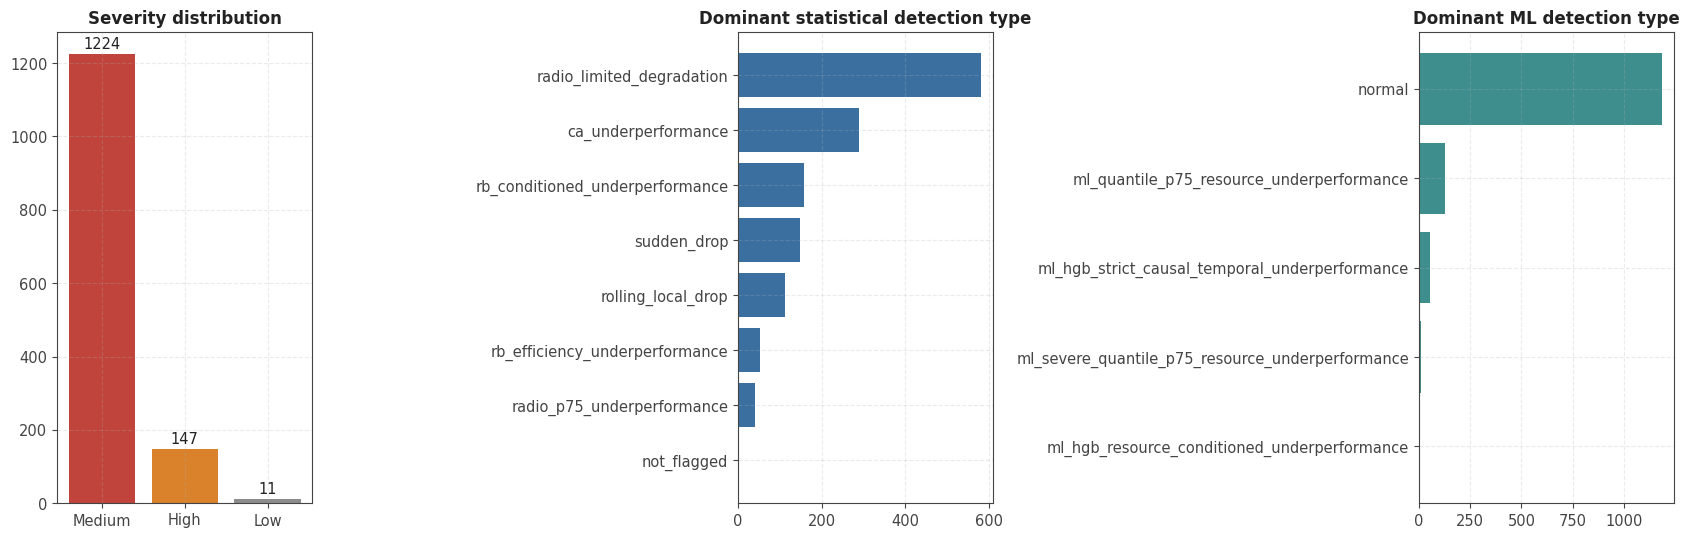

Statistical-only detections (ML says 'normal'): 85.9%


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

ax=axes[0]
sev_counts = incidents_df['severity'].value_counts()
ax.bar(sev_counts.index, sev_counts.values, color=[COLORS['red'], COLORS['orange'], COLORS['grey']])
ax.set_title('Severity distribution')
for i,v in enumerate(sev_counts.values): ax.text(i, v+15, f'{v}', ha='center')

ax=axes[1]
stat_counts = incidents_df['dominant_statistical_type'].value_counts()
ax.barh(stat_counts.index[::-1], stat_counts.values[::-1], color=COLORS['blue'])
ax.set_title('Dominant statistical detection type')

ax=axes[2]
ml_counts = incidents_df['dominant_ml_type'].value_counts()
ax.barh(ml_counts.index[::-1], ml_counts.values[::-1], color=COLORS['teal'])
ax.set_title('Dominant ML detection type')
plt.tight_layout(); plt.show()

print(f"Statistical-only detections (ML says 'normal'): {(incidents_df['dominant_ml_type']=='normal').mean()*100:.1f}%")


**Finding:** `radio_limited_degradation` is the single largest statistical detection type (581/1,382,
42%) — and it maps **perfectly** onto `coverage_or_planning_review`: every single one of those 581
incidents has that flag set to `True` (checked directly, zero exceptions), while every other detection
type is a mixed bag. That's not a soft correlation, it's a deterministic rule upstream. Also striking:
the ML layer only actively flags **14%** of incidents (`dominant_ml_type != 'normal'`) — the large majority
of this dataset's anomalies are statistical-detection-only, with the ML model agreeing they look "normal"
by its own criteria. Worth keeping in mind when weighing how much to trust either signal on its own.


### 15.2 Priority, confidence, and persistence scores


,peak_row_priority_0_100,episode_adjusted_priority_0_100,incident_final_priority_0_100,priority_score_0_100,impact_score_0_100,detection_confidence_0_100,persistence_score_0_100
count,1382.0,1382.0,1382.0,1382.0,1382.0,1382.0,1382.0
mean,75.9,64.6,56.7,56.7,52.3,62.0,18.6
std,8.7,7.3,6.8,6.8,8.5,13.1,7.5
min,51.0,41.8,34.3,34.3,30.9,32.0,13.2
25%,69.4,59.4,51.9,51.9,45.5,53.8,13.2
50%,76.6,64.6,56.5,56.5,52.3,62.7,16.2
75%,82.0,69.4,60.7,60.7,58.1,67.7,19.7
max,99.0,87.0,78.4,78.4,96.2,100.0,86.7


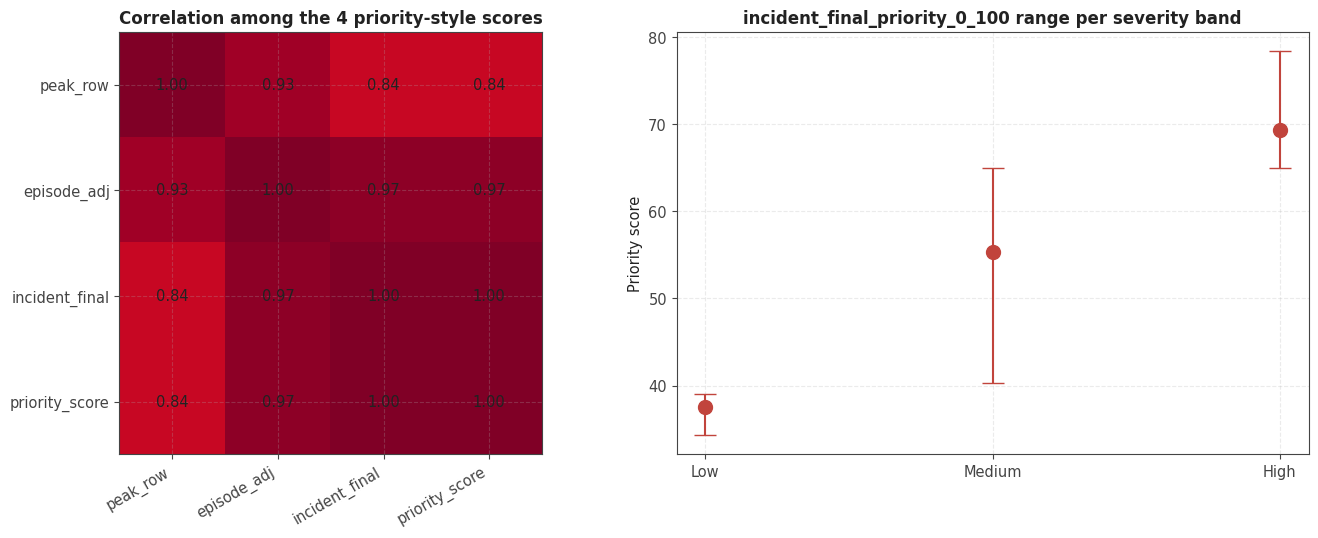

In [36]:
score_cols = ['peak_row_priority_0_100','episode_adjusted_priority_0_100','incident_final_priority_0_100',
              'priority_score_0_100','impact_score_0_100','detection_confidence_0_100','persistence_score_0_100']
display(incidents_df[score_cols].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax=axes[0]
corr = incidents_df[['peak_row_priority_0_100','episode_adjusted_priority_0_100','incident_final_priority_0_100','priority_score_0_100']].corr()
im = ax.imshow(corr, cmap='YlOrRd', vmin=0, vmax=1)
labels = ['peak_row','episode_adj','incident_final','priority_score']
ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
ax.set_title('Correlation among the 4 priority-style scores')

ax=axes[1]
sev_priority = incidents_df.groupby('severity')['incident_final_priority_0_100'].agg(['mean','min','max'])
sev_priority = sev_priority.reindex(['Low','Medium','High'])
ax.errorbar(sev_priority.index, sev_priority['mean'],
            yerr=[sev_priority['mean']-sev_priority['min'], sev_priority['max']-sev_priority['mean']],
            fmt='o', markersize=10, capsize=8, color=COLORS['red'])
ax.set_title('incident_final_priority_0_100 range per severity band')
ax.set_ylabel('Priority score')
plt.tight_layout(); plt.show()


**Finding:** `incident_final_priority_0_100` and `priority_score_0_100` are essentially the same number
(correlation 1.00) -- likely redundant fields rather than two independent signals. More usefully: the
severity bands are **cleanly separable** on `incident_final_priority_0_100` with zero overlap in this
dataset -- Low sits at 34-39, Medium at 40-65, High at 65-78. That's a strong, verifiable consistency
check: the categorical severity label isn't an independent judgment call, it's a direct readout of the
continuous priority score.


### 15.3 Location reliability — validates an earlier decision in this project


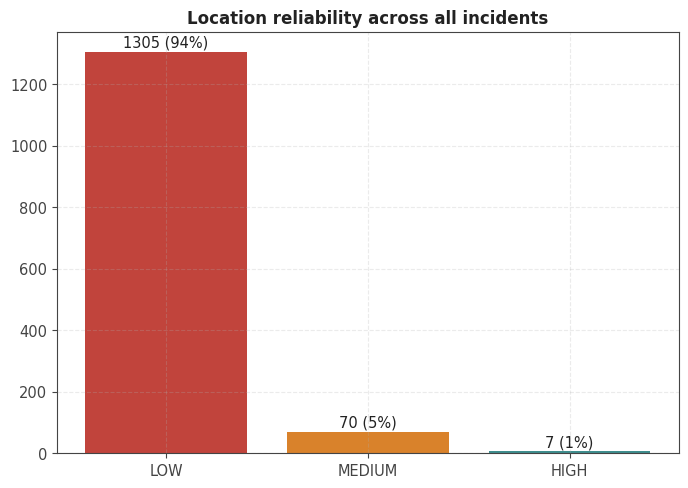

count    1382.00
mean        5.60
std        11.62
min         0.00
25%         0.00
50%         0.01
75%         6.65
max       132.93
Name: location_uncertainty_radius_m, dtype: float64


In [37]:
loc_rel = incidents_df['location_reliability'].value_counts()
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(loc_rel.index, loc_rel.values, color=[COLORS['red'], COLORS['orange'], COLORS['teal']])
ax.set_title('Location reliability across all incidents')
for i,v in enumerate(loc_rel.values): ax.text(i, v+15, f'{v} ({v/len(incidents_df)*100:.0f}%)', ha='center')
plt.tight_layout(); plt.show()

print(incidents_df['location_uncertainty_radius_m'].describe().round(2))


**Finding:** **94% of incidents have LOW location reliability**, with an uncertainty radius reaching up
to 133 meters in the tail. This is the concrete data behind an earlier project decision: a PCI-collision
check computed from this file's coordinates was deliberately dropped as a live cause, precisely because
the underlying location data couldn't be trusted enough to confidently say two sites were genuinely close
together. This chart is the direct evidence for why that caution was warranted.


### 15.4 The `requires_human_review` outliers


In [38]:
review_cases = incidents_df[incidents_df['requires_human_review']==True]
print(f"Only {len(review_cases)} of {len(incidents_df)} incidents ({len(review_cases)/len(incidents_df)*100:.2f}%) are flagged for human review.")
display(review_cases[['incident_id','severity','incident_final_priority_0_100','detection_confidence_0_100',
                       'dominant_statistical_type','dominant_ml_type']])


Only 4 of 1382 incidents (0.29%) are flagged for human review.


,incident_id,severity,incident_final_priority_0_100,detection_confidence_0_100,dominant_statistical_type,dominant_ml_type
169,INC-000170,Medium,42.29,42.54,rb_conditioned_underperformance,normal
181,INC-000182,Medium,52.38,60.22,rb_conditioned_underperformance,normal
431,INC-000432,Medium,51.86,63.64,not_flagged,ml_quantile_p75_resource_underperformance
626,INC-000627,Medium,49.02,48.92,rb_conditioned_underperformance,normal


**Finding:** human review is vanishingly rare (4 incidents, 0.3%) -- this pipeline is designed to be
confident enough to auto-classify almost everything. One of the four (`INC-000432`) is flagged despite its
`dominant_statistical_type` being `not_flagged` -- the only such case in the entire dataset -- which is
exactly the kind of internally-inconsistent record (something triggered a review, yet the primary
statistical detector didn't flag a type) that a human-review gate exists to catch.


## 16. Full RCA of the Incidents Dataset — driven by the project's JSON knowledge base

Everything in Sections 1-15 works from the row-level drive-test CSV. This section is different: it applies
the project's shared knowledge base (`causes.json`, `kpi_rules.json`, `solutions.json` — the same three
files behind `classify_incidents.py`) to the **incidents-level dataset** (1,382 aggregated incidents), using
the full JSON export rather than the narrower CSV, since the CSV is missing RSRP/SINR/CQI/throughput/CA
fields that most causes need to fire at all.

The engine below is a direct, faithful port of `classify_incidents.py`: it **loads and executes
`kpi_rules.json`'s condition trees generically** — no thresholds are hardcoded in this notebook either.
Editing a number in `kpi_rules.json` changes what fires here too, with no code change required.


In [39]:
import json
incidents_causes = json.load(open('causes.json'))
incidents_kpi_rules = json.load(open('kpi_rules.json'))
incidents_solutions = {s['id']: s for s in json.load(open('solutions.json'))['solutions']}
incidents_raw = json.load(open('rca_anomaly_incidents_full_compact.json'))
print(f"Loaded {len(incidents_raw)} incidents, {len(incidents_kpi_rules['rules'])} KPI rules, {len(incidents_solutions)} solution entries")

id_to_cause, id_to_subcat = {}, {}
for cat in incidents_causes['priority_categories']:
    for sc in cat['subcategories']:
        for c in sc['causes_list']:
            id_to_cause[c['id']] = c
            id_to_subcat[c['id']] = {"category": cat['category'], "subcategory": sc['subcategory'], "parent_id": sc['parent_id']}

CATEGORY_DISPLAY_OVERRIDE = {"C03": "Coverage", "C04": "Radio Link Failure (Interference)"}


Loaded 1382 incidents, 14 KPI rules, 14 solution entries


### 16.1 Generic condition evaluator (mirrors `classify_incidents.py` exactly)


In [40]:
def evaluate_condition(cond, f):
    if cond.get('not_computable'):
        return False
    if 'all' in cond:
        return all(evaluate_condition(c, f) for c in cond['all'])
    if 'any' in cond:
        return any(evaluate_condition(c, f) for c in cond['any'])
    if 'not' in cond:
        return not evaluate_condition(cond['not'], f)
    field, op, value = cond['field'], cond['op'], cond['value']
    fv = f.get(field)
    if fv is None:
        return False
    if op == '==': return fv == value
    if op == '!=': return fv != value
    if op == '<':  return fv < value
    if op == '<=': return fv <= value
    if op == '>':  return fv > value
    if op == '>=': return fv >= value
    if op == 'in': return fv in value
    raise ValueError(f"unknown operator {op}")

def evaluate_gate(rule, f):
    logic = rule.get('gate_logic', 'ALL')
    conds = rule['gate_conditions']
    return all(evaluate_condition(c, f) for c in conds) if logic=='ALL' else any(evaluate_condition(c, f) for c in conds)

def evaluate_supporting_evidence(rule, f):
    return [ev['id'] for ev in rule.get('supporting_evidence', []) if evaluate_condition(ev['detection_conditions'], f)]


### 16.2 Feature extraction — one flat dict per incident


In [41]:
def gg(d, path, default=None):
    cur = d
    for p in path.split('.'):
        if cur is None: return default
        cur = cur.get(p) if isinstance(cur, dict) else default
        if cur is None: return default
    return cur

def nn(x): return isinstance(x, (int, float))

def extract_incident(rec):
    f = {}
    f['rsrp'] = gg(rec, 'radio_kpis.rsrp_median_dbm'); f['rsrq'] = gg(rec, 'radio_kpis.rsrq_median_db')
    f['sinr'] = gg(rec, 'radio_kpis.sinr_median_db'); f['cqi'] = gg(rec, 'radio_kpis.cqi_median')
    f['mcs'] = gg(rec, 'radio_kpis.mcs_median'); f['bler'] = gg(rec, 'radio_kpis.bler_median_pct')
    f['rb_usage'] = gg(rec, 'resource_kpis.rb_usage_median'); f['tp_per_rb'] = gg(rec, 'resource_kpis.throughput_per_rb_median')
    f['rb_med_high'] = gg(rec, 'resource_kpis.rb_medium_or_high_usage', False)
    f['actual_tp'] = gg(rec, 'throughput.actual_median_mbps'); f['expected_tp'] = gg(rec, 'throughput.expected_median_mbps')
    f['ca_active'] = gg(rec, 'ca_context.ca_active', False); f['carrier_count'] = gg(rec, 'ca_context.carrier_count_median')
    f['scell_rsrp'] = gg(rec, 'ca_context.scell1_rsrp_median_dbm'); f['scell_sinr'] = gg(rec, 'ca_context.scell1_sinr_median_db')
    f['scell_cqi'] = gg(rec, 'ca_context.scell1_cqi_median'); f['scell_bler'] = gg(rec, 'ca_context.scell1_bler_median_pct')
    f['temporal_drop'] = gg(rec, 'statistical_evidence.temporal_drop', False)
    f['sustained_window'] = gg(rec, 'statistical_evidence.sustained_window', False)
    f['low_tail_consensus'] = gg(rec, 'statistical_evidence.low_tail_consensus', False)
    f['detection_case'] = rec.get('detection_case'); f['severity'] = rec.get('severity')
    f['cell_prb_util'] = gg(rec, 'rca_required_kpis.cell_prb_utilization_pct')
    f['near_ho'] = bool(gg(rec, 'rca_required_kpis.near_handover_mobility_flag', False))
    f['near_rach_fail'] = bool(gg(rec, 'rca_required_kpis.near_rach_failure_flag', False))
    f['neighbor_avail'] = gg(rec, 'rca_required_kpis.neighbor_cell_availability')
    f['rank'] = gg(rec, 'rca_required_kpis.lte_rank'); f['ue_speed'] = gg(rec, 'rca_required_kpis.ue_speed_kmh')
    f['gap_rsrp'] = gg(rec, 'rca_required_kpis.serving_minus_best_neighbor_rsrp')
    f['ho_count_pm5s'] = gg(rec, 'rca_required_kpis.handover_mobility_count_pm5s')
    f['ho_dwell'] = gg(rec, 'rca_required_kpis.ho_dwell_time_s')
    f['cell_median_tp'] = gg(rec, 'cell_performance_context.cell_median_tp_mbps')
    f['cell_bad_rank'] = gg(rec, 'cell_performance_context.cell_bad_rank', False)

    rach_reason = gg(rec, 'rca_required_kpis.rach_reason', [])
    f['rlf_present'] = isinstance(rach_reason, list) and 'Radio link Failure' in rach_reason

    f['demand_confirmed'] = (f['detection_case']=='rb_conditioned_expected_underperformance') or bool(f['rb_med_high'])
    f['demand_confirmed_broad'] = nn(f['expected_tp']) and f['expected_tp'] > 0.1
    f['bad_session'] = bool(f['sustained_window']) and bool(f['low_tail_consensus'])
    f['fallback'] = True

    f['underperform_80pct'] = nn(f['expected_tp']) and nn(f['actual_tp']) and f['actual_tp'] < 0.8*f['expected_tp']
    own_radio_bad = (nn(f['rsrp']) and f['rsrp']<-110) or (nn(f['sinr']) and f['sinr']<0)
    f['own_radio_normal'] = (nn(f['rsrp']) and f['rsrp']>=-110) and (nn(f['sinr']) and f['sinr']>=0) and not own_radio_bad
    f['mimo_pattern'] = nn(f['sinr']) and f['sinr']>=15 and nn(f['rank']) and f['rank']==1
    f['not_mobility'] = not f['near_ho']; f['not_mimo'] = not f['mimo_pattern']
    f['near_zero_tp'] = nn(f['actual_tp']) and f['actual_tp'] < 0.05
    f['session_collapse'] = bool(f['temporal_drop']) and bool(f['bad_session'])
    f['cell_prb_util_spike'] = nn(f['cell_prb_util']) and f['cell_prb_util'] >= 80
    f['neighbor_avail_drop'] = nn(f['neighbor_avail']) and f['neighbor_avail'] < 80
    return f


### 16.3 Two-function classifier, priority 1-4 then priority 5-6, driven by `kpi_rules.json`


In [42]:
def classify_priority_1_to_4(f):
    for rule in incidents_kpi_rules['rules']:
        if not (1 <= rule['priority'] <= 4): continue
        if not evaluate_gate(rule, f): continue
        if 'alternatives' in rule:
            for alt in rule['alternatives']:
                if all(evaluate_condition(c, f) for c in alt['gate_conditions']):
                    return (alt['id'], evaluate_supporting_evidence(rule, f))
            continue
        return (rule['parent_id'], evaluate_supporting_evidence(rule, f))
    return (None, [])

def classify_priority_5_to_6(f):
    for rule in incidents_kpi_rules['rules']:
        if not (5 <= rule['priority'] <= 6): continue
        if evaluate_gate(rule, f):
            return (rule['parent_id'], evaluate_supporting_evidence(rule, f))
    return (None, [])

def classify_fallback(f):
    for rule in incidents_kpi_rules['rules']:
        if rule['priority']==7 and rule['parent_id']=='C14' and evaluate_gate(rule, f):
            return 'C14'
    return 'C15'

def classify_incident(rec):
    f = extract_incident(rec)
    if not f['demand_confirmed_broad']:
        cid, ev = 'C15', []
    else:
        cid, ev = classify_priority_1_to_4(f)
        if cid is None: cid, ev = classify_priority_5_to_6(f)
        if cid is None: cid, ev = classify_fallback(f), []
    subcat = id_to_subcat[cid]
    problem_name = subcat['subcategory'] if cid==subcat['parent_id'] else f"{subcat['subcategory']} - {id_to_cause[cid]['name']}"
    return cid, problem_name, subcat, ev, f

results = [classify_incident(rec) for rec in incidents_raw]
incidents_df_full = incidents_raw  # keep original records alongside results for reference


### 16.4 Root cause distribution


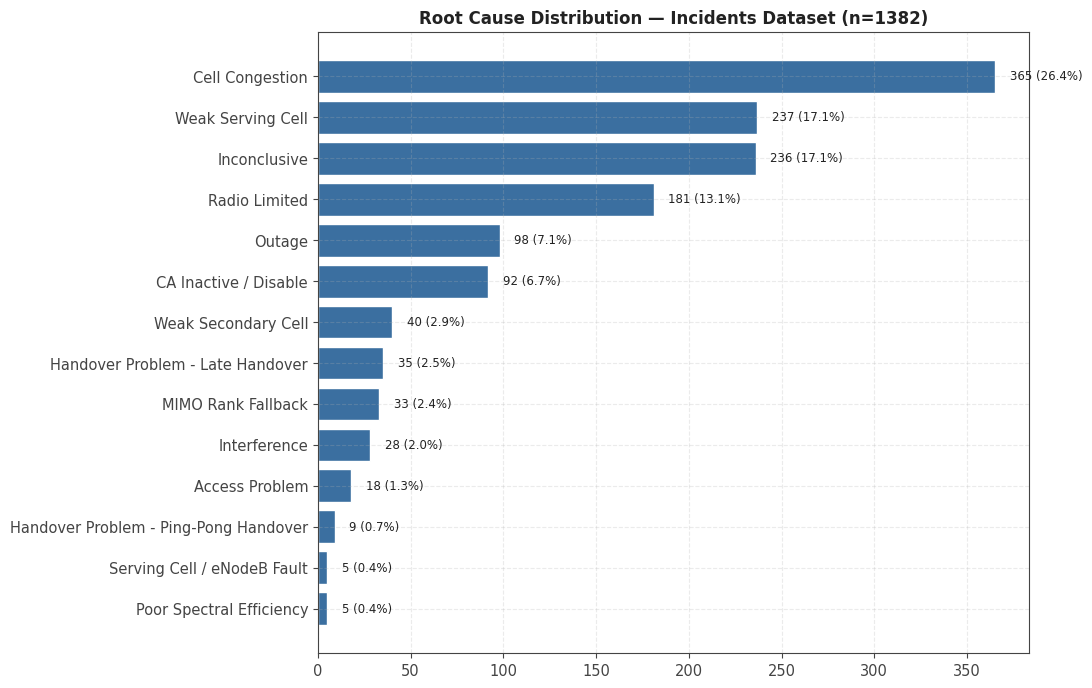

  Cell Congestion: 365
  Weak Serving Cell: 237
  Inconclusive: 236
  Radio Limited: 181
  Outage: 98
  CA Inactive / Disable: 92
  Weak Secondary Cell: 40
  Handover Problem - Late Handover: 35
  MIMO Rank Fallback: 33
  Interference: 28
  Access Problem: 18
  Handover Problem - Ping-Pong Handover: 9
  Serving Cell / eNodeB Fault: 5
  Poor Spectral Efficiency: 5


In [43]:
from collections import Counter
problem_names = [r[1] for r in results]
dist = Counter(problem_names)

fig, ax = plt.subplots(figsize=(11, 7))
order = [k for k,_ in dist.most_common()]
values = [dist[k] for k in order]
ax.barh(order, values, color=COLORS['blue'], edgecolor='white')
ax.invert_yaxis()
ax.set_title(f'Root Cause Distribution — Incidents Dataset (n={len(incidents_raw)})', fontweight='bold')
for i,v in enumerate(values):
    ax.text(v+8, i, f'{v} ({v/len(incidents_raw)*100:.1f}%)', va='center', fontsize=8.5)
plt.tight_layout(); plt.show()

for name, n in dist.most_common():
    print(f"  {name}: {n}")


**Finding:** Cell Congestion and Weak Serving Cell dominate here, same as in the row-level CSV analysis
(Sections 1-14) — a reassuring cross-dataset consistency check, even though these two datasets were built
from different aggregation levels. Serving Cell/eNodeB Fault (the RLF-confirmed cause) and both Handover
patterns remain small, high-confidence findings rather than bulk categories, exactly as intended.


### 16.5 Sample full diagnoses, with restored citation URLs


In [44]:
def build_reason_text(cid, f):
    tmpl = id_to_cause[cid]['reason_template']
    vals = {'lte_rsrp': f.get('rsrp'), 'lte_rsrq': f.get('rsrq'), 'lte_sinr': f.get('sinr'), 'lte_cqi': f.get('cqi'),
            'lte_mcs': f.get('mcs'), 'lte_bler': f.get('bler'), 'rb_utilization_pct': f.get('rb_usage'),
            'carrier_count': f.get('carrier_count'), 'cell_prb_utilization_pct': f.get('cell_prb_util'),
            'throughput_gap_p75': (round(f['expected_tp']-f['actual_tp'],2) if nn(f.get('expected_tp')) and nn(f.get('actual_tp')) else None),
            'scell_rsrp': f.get('scell_rsrp'), 'scell_sinr': f.get('scell_sinr'), 'scell_cqi': f.get('scell_cqi'),
            'scell_bler': f.get('scell_bler'), 'neighbor_cell_availability': f.get('neighbor_avail'),
            'handover_count': f.get('ho_count_pm5s'), 'ue_speed_kmh': f.get('ue_speed'), 'avg_rank': f.get('rank'),
            'dl_bandwidth_mhz': None, 'dl_mcs': f.get('mcs'), 'scell_rb_count': None}
    def fmt(v): return round(v,2) if isinstance(v,float) else v
    present = {k: fmt(v) for k,v in vals.items() if v is not None}
    missing = {k: 'n/a' for k,v in vals.items() if v is None}
    try: return tmpl.format(**present, **missing)
    except Exception: return tmpl

for target_cid in ['C05', 'C06', 'C11']:
    match = next((r for r in results if r[0]==target_cid), None)
    if not match: continue
    cid, problem_name, subcat, ev, f = match
    sol = incidents_solutions.get(cid, {})
    print(f"=== {problem_name} ({cid}) ===")
    print("Reason:", build_reason_text(cid, f))
    print("Solutions:")
    for a in sol.get('recommended_actions', []):
        if a.get('applies_if') is None or a.get('applies_if') in (ev+[cid]):
            print("  -", a['action'])
    for ref in sol.get('standards_and_vendor_references', []):
        print(f"  Reference: {ref['source']} -> {ref.get('url')}")
    print()


=== Serving Cell / eNodeB Fault (C05) ===
Reason: A Radio Link Failure was declared while this UE's own radio conditions (RSRP -102.29 dBm, SINR 11.07 dB) were normal -- not explained by coverage or interference, pointing at the serving cell/eNodeB itself.
Solutions:
  - Check OSS alarms/counters for the serving site during this exact time window -- Radio Link Failure with normal own-radio conditions is the classic signature of a site/hardware fault, not an RF problem.
  - Review Mobility Robustness Optimization (MRO) counters for too-late or too-early handover contributing to this failure type.
  - No RF tuning action is appropriate here until an outage/alarm event is confirmed or ruled out.
  Reference: 3GPP TS 36.331 clause 5.3.11.3 (RLF), cross-referenced with SON Mobility Robustness Optimization -> https://www.sharetechnote.com/html/Handbook_LTE_RadioLinkFailure.html

=== Outage (C06) ===
Reason: A throughput/session collapse occurred while this UE's own radio conditions (RSRP -10